**Code cell purpose:** Cell below is extremely important! It imports the relevant packages to be utilized throughout the entire notebook, also choosing desired display settings. Cell must be ran prior to any other cells are to ensure proper reproducibility.

In [2]:
## Initializing the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import mean_squared_error
from IPython.display import display

import os
import itertools
import warnings
from pathlib import Path
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# **Data Loading, Cleaning, and Exploratory Data Analysis**

Our code covers work for Track A, Project 3. In this section, we prepare the weekly FRED initial unemployment insurance claims data. For the final submission, the notebook expects a folder titled "Data" in the same directory as this notebook. Within that folder should be the four required FRED CSV files labeled "CAICLAIMS.csv", "HIICLAIMS.csv", "INICLAIMS.csv", and "NYICLAIMS.csv". Generally, the raw FRED CSV files that we utilize here are already quite clean, however, we still wanted to make sure that they contained good time series for the process of forecasting. Mainly, this section performs work such as checking for missing values, duplicates, date parsing, negative values, etc. Additionally, work is done for summary statistics, annual patterns, and other relevant EDA steps!

## **1. Setting up the Datasets and Loading Helper Functions**

Our project, as aforementioned, utilizes four state-level FRED initial claims series. In the cell below, all data is loaded through the local "Data" folder, and there are also a couple of brief helper functions created which are beneficial for the general flow of code to come later. 

**Code cell purpose:** This cell, being early in our setup, is basic in purpose. Specifically, it works to define things such as our list of states, labels for the states, the local data path that is being used, and a couple brief helper functions which are utilized for both loading/cleaning our FRED CSVs! 

In [3]:
## Datasets of interest, naming them, etc.
datasets = ["CAICLAIMS", "NYICLAIMS", "INICLAIMS", "HIICLAIMS"]

state_names = {
    "CAICLAIMS": "California",
    "NYICLAIMS": "New York",
    "INICLAIMS": "Indiana",
    "HIICLAIMS": "Hawaii"
}

## Relevant local path for data
data_dir = Path("Data")

## Function to check for relevant path
def claims_path(code):
    path = data_dir / f"{code}.csv"
    if not path.exists():
        raise FileNotFoundError(f"You are missing {path}! Please ensure to include this CSV in the Data folder.")
    return path

## Function for date column presence
def date_column(raw):
    options = [col for col in raw.columns if "date" in col.lower()]
    return options[0] if options else raw.columns[0]

## Function for claims column checking
def claims_column(raw, code, date_col):
    if code in raw.columns:
        return code
    options = [col for col in raw.columns if col != date_col]
    if not options:
        raise ValueError(f"There were no claims column found for {code}!")
    return options[0]

## Function to return base claims in dataframe
def base_claims_frame(raw, code):
    date_col = date_column(raw)
    value_col = claims_column(raw, code, date_col)
    return pd.DataFrame({
        "Date": pd.to_datetime(raw[date_col], errors="coerce"),
        "Claims_Raw": pd.to_numeric(raw[value_col], errors="coerce"),
        "StateCode": code,
        "State": state_names[code]
    })

## Function to have cleaned claims dataframe
def clean_claims_frame(df):
    df = df.sort_values("Date").drop_duplicates(subset=["Date"], keep="first").reset_index(drop=True)
    df["Claims_Was_Missing"] = df["Claims_Raw"].isna()
    df["Claims"] = df["Claims_Raw"].interpolate(method="linear", limit_direction="both")
    return df

## Function that takes raw values and cleans them using prior function
def load_and_clean_claims(code):
    raw = pd.read_csv(claims_path(code))
    raw.columns = raw.columns.astype(str).str.strip()
    return clean_claims_frame(base_claims_frame(raw, code))

**One important thing to note about the above clean_claims_frame function. Specifically, with our current structure, we have that the raw FRED CSV values end up being preserved in the Claims_Raw column. However, as some observations are found to be missing in the original claims column, i.e. Hawaii, a flag is generated called Claims_Was_Missing to indicate problem rows. Additionally, for the purpose of good modeling, a cleaned variable titled Claims is generated in which the aforementioned problem values are filled-in through the use of linear interpolation within each state's time series. Interpolated values are NOT the same as original reported claims values, instead being a manual pre-processing step that we take such that we can actually run time-series models on complete weekly data.**

## **2. Loading All of Our Relevant State Files**

This cell works to generate a single cleaned dataframe for each state, afterwards storing them in an object titled "claims_dfs". We also have another object, "combined_claims", which is a stacked dataframe that is useful for relevant EDA work to produce tables and plots of interest.

**Code cell purpose:** The cell below simply loads the four relevant state files, stacks them such that there is only one dataframe for analysis, and then generates date-based variables which are useful for EDA work!

In [4]:
## Generating the object
claims_dfs = {}

## Working to loop through the datasets, making claims_dfs dataset
for code in datasets:
    df = load_and_clean_claims(code)
    claims_dfs[code] = df
    globals()[code] = df

## Generated the combined_claims dataset
combined_claims = pd.concat(claims_dfs.values(), ignore_index=True)
combined_claims["Year"] = combined_claims["Date"].dt.year
combined_claims["Month"] = combined_claims["Date"].dt.month
combined_claims["Week"] = combined_claims["Date"].dt.isocalendar().week.astype(int)

print("Loaded datasets:")
for code in datasets:
    print(f"{code}: {claims_dfs[code].shape[0]:,} rows")

display(combined_claims.head())

Loaded datasets:
CAICLAIMS: 2,097 rows
NYICLAIMS: 2,096 rows
INICLAIMS: 2,096 rows
HIICLAIMS: 2,141 rows


,Date,Claims_Raw,StateCode,State,Claims_Was_Missing,Claims,Year,Month,Week
0,1986-02-08,"75,972.00",CAICLAIMS,California,False,"75,972.00",1986,2,6
1,1986-02-15,"54,595.00",CAICLAIMS,California,False,"54,595.00",1986,2,7
2,1986-02-22,"68,513.00",CAICLAIMS,California,False,"68,513.00",1986,2,8
3,1986-03-01,"65,424.00",CAICLAIMS,California,False,"65,424.00",1986,3,9
4,1986-03-08,"66,436.00",CAICLAIMS,California,False,"66,436.00",1986,3,10


## **3. Checking General Data Quality**

Prior to extensive modeling, we check to ensure that each of the four time series has usable structure. Specifically, we look to ensure that there is only one observation each week, valid dates, no duplicates, numeric and non-negative claims, etc. Additionally, work is done to record raw missing claims values, i.e. in the case of Hawaii where there are indeed some missing observations.

**Code cell purpose:** Cell below works to generate a basic data-quality table. Utilized for verification purposes, mainly in regard to dates, missing values, duplicates, negative values, etc. 

In [5]:
## Generating the object
quality_rows = []

## Looping through each CSV such that we have our cleaned dataset
for code in datasets:
    df = claims_dfs[code].copy()
    date_diffs = df["Date"].diff().dropna().dt.days

    quality_rows.append({
        "dataset": code,
        "state": state_names[code],
        "rows": len(df),
        "start_date": df["Date"].min().date(),
        "end_date": df["Date"].max().date(),
        "missing_dates": int(df["Date"].isna().sum()),
        "missing_claims_raw": int(df["Claims_Raw"].isna().sum()),
        "missing_claims_after_clean": int(df["Claims"].isna().sum()),
        "interpolated_claims": int(df["Claims_Was_Missing"].sum()),
        "duplicate_dates_after_clean": int(df["Date"].duplicated().sum()),
        "negative_claims": int((df["Claims"] < 0).sum()),
        "nonweekly_gaps": int((date_diffs != 7).sum()),
        "min_gap_days": date_diffs.min() if len(date_diffs) > 0 else np.nan,
        "max_gap_days": date_diffs.max() if len(date_diffs) > 0 else np.nan
    })

## Displaying results after converting to dataframe, seeing how much is missing, negative, duplicated, etc.
quality_summary = pd.DataFrame(quality_rows)
display(quality_summary)

,dataset,state,rows,start_date,end_date,missing_dates,missing_claims_raw,missing_claims_after_clean,interpolated_claims,duplicate_dates_after_clean,negative_claims,nonweekly_gaps,min_gap_days,max_gap_days
0,CAICLAIMS,California,2097,1986-02-08,2026-04-11,0,5,0,5,0,0,0,7,7
1,NYICLAIMS,New York,2096,1986-02-15,2026-04-11,0,0,0,0,0,0,0,7,7
2,INICLAIMS,Indiana,2096,1986-02-15,2026-04-11,0,0,0,0,0,0,0,7,7
3,HIICLAIMS,Hawaii,2141,1985-04-06,2026-04-11,0,48,0,48,0,0,0,7,7


## **4. Inspecting the Missing Values Present**

Below, we have a table which showcases the original rows that contain missing values for the claims prior to interpolation/estimation. Important to have this such that both us (and others working through the notebook) are able to understand which specific rows are odd observations.

**Code cell purpose:** Cell below provides transparency in our cleaning process, mainly by listing out the rows which contained missing claims prior to any interpolation.

In [6]:
## Defining our missing_rows object accordingly
missing_rows = (
    combined_claims
    .loc[combined_claims["Claims_Was_Missing"], ["State", "StateCode", "Date", "Claims_Raw", "Claims"]]
    .sort_values(["State", "Date"])
)

## Getting the actual amount
print(f"Total originally missing claims values: {len(missing_rows):,}")

## Listing out all rows missing raw claims
if len(missing_rows) > 0:
    display(missing_rows.head(20))
else:
    print("There were no raw claims values which were missing found here!")

Total originally missing claims values: 53


,State,StateCode,Date,Claims_Raw,Claims
58,California,CAICLAIMS,1987-03-21,NaN,"54,067.00"
73,California,CAICLAIMS,1987-07-04,NaN,"47,279.60"
74,California,CAICLAIMS,1987-07-11,NaN,"47,188.20"
75,California,CAICLAIMS,1987-07-18,NaN,"47,096.80"
76,California,CAICLAIMS,1987-07-25,NaN,"47,005.40"
6290,Hawaii,HIICLAIMS,1985-04-13,NaN,"1,365.96"
6291,Hawaii,HIICLAIMS,1985-04-20,NaN,"1,361.91"
6292,Hawaii,HIICLAIMS,1985-04-27,NaN,"1,357.87"
6293,Hawaii,HIICLAIMS,1985-05-04,NaN,"1,353.82"
6294,Hawaii,HIICLAIMS,1985-05-11,NaN,"1,349.78"


## **5. Details Regarding Duplicates and Gaps in Dates**

This cell works to display any cases in which we have state-date duplicates or non-weekly date gaps, both of which are major issues for our procedures. Desire no problem rows after cleaning process.

**Code cell purpose:** Cell below directly prints the checks for duplicate date and non-weekly gaps in dates. 

In [7]:
## Looping through each of our four states and ensuring that there are no problem rows after cleaning!
for code in datasets:
    df = claims_dfs[code].copy()

    ## Checking the duplicated dates after cleaning. Want NONE!
    duplicated_dates = df.loc[df["Date"].duplicated(keep=False), ["Date", "Claims"]]

    ## Checking the date gaps other than exactly 7 days. Want NONE!
    gap_check = df[["Date"]].copy()
    gap_check["gap_days"] = gap_check["Date"].diff().dt.days
    nonweekly_gaps = gap_check.loc[gap_check["gap_days"].notna() & (gap_check["gap_days"] != 7)]

    print(f"\n{code} — {state_names[code]}")
    print(f"Duplicated dates after cleaning: {len(duplicated_dates):,}")
    print(f"Non-weekly gaps after cleaning: {len(nonweekly_gaps):,}")

    if len(nonweekly_gaps) > 0:
        display(nonweekly_gaps.head(10))


CAICLAIMS — California
Duplicated dates after cleaning: 0
Non-weekly gaps after cleaning: 0

NYICLAIMS — New York
Duplicated dates after cleaning: 0
Non-weekly gaps after cleaning: 0

INICLAIMS — Indiana
Duplicated dates after cleaning: 0
Non-weekly gaps after cleaning: 0

HIICLAIMS — Hawaii
Duplicated dates after cleaning: 0
Non-weekly gaps after cleaning: 0


## **6. Previewing Rows and Exploring Basic Shape of Dataset**

Here, we go through and complete a quick row-level sanity check for each of the four states. What makes this useful is that, through such checks, we confirm that date range and claims values are logical and look reasonable for use later on, saving us trouble when attempting to run more complex summaries.

**Code cell purpose:** Below, the cell simply previews the initial and last rows for each state to make sure that our loaded series appear logical. 

In [8]:
## Loading the first and last couple rows for each state's claims!
for code in datasets:
    print(f"\n{code} — {state_names[code]}")
    display(claims_dfs[code].head(5))
    display(claims_dfs[code].tail(5))



CAICLAIMS — California


,Date,Claims_Raw,StateCode,State,Claims_Was_Missing,Claims
0,1986-02-08,"75,972.00",CAICLAIMS,California,False,"75,972.00"
1,1986-02-15,"54,595.00",CAICLAIMS,California,False,"54,595.00"
2,1986-02-22,"68,513.00",CAICLAIMS,California,False,"68,513.00"
3,1986-03-01,"65,424.00",CAICLAIMS,California,False,"65,424.00"
4,1986-03-08,"66,436.00",CAICLAIMS,California,False,"66,436.00"


,Date,Claims_Raw,StateCode,State,Claims_Was_Missing,Claims
2092,2026-03-14,"38,273.00",CAICLAIMS,California,False,"38,273.00"
2093,2026-03-21,"37,819.00",CAICLAIMS,California,False,"37,819.00"
2094,2026-03-28,"38,010.00",CAICLAIMS,California,False,"38,010.00"
2095,2026-04-04,"40,140.00",CAICLAIMS,California,False,"40,140.00"
2096,2026-04-11,"40,874.00",CAICLAIMS,California,False,"40,874.00"



NYICLAIMS — New York


,Date,Claims_Raw,StateCode,State,Claims_Was_Missing,Claims
0,1986-02-15,20647,NYICLAIMS,New York,False,20647
1,1986-02-22,21499,NYICLAIMS,New York,False,21499
2,1986-03-01,21738,NYICLAIMS,New York,False,21738
3,1986-03-08,22049,NYICLAIMS,New York,False,22049
4,1986-03-15,20144,NYICLAIMS,New York,False,20144


...

,Date,Claims_Raw,StateCode,State,Claims_Was_Missing,Claims
0,1986-02-15,8089,INICLAIMS,Indiana,False,8089
1,1986-02-22,7304,INICLAIMS,Indiana,False,7304
2,1986-03-01,7746,INICLAIMS,Indiana,False,7746
3,1986-03-08,7724,INICLAIMS,Indiana,False,7724
4,1986-03-15,6279,INICLAIMS,Indiana,False,6279


,Date,Claims_Raw,StateCode,State,Claims_Was_Missing,Claims
2091,2026-03-14,2608,INICLAIMS,Indiana,False,2608
2092,2026-03-21,2418,INICLAIMS,Indiana,False,2418
2093,2026-03-28,2279,INICLAIMS,Indiana,False,2279
2094,2026-04-04,2727,INICLAIMS,Indiana,False,2727
2095,2026-04-11,3629,INICLAIMS,Indiana,False,3629



HIICLAIMS — Hawaii


,Date,Claims_Raw,StateCode,State,Claims_Was_Missing,Claims
0,1985-04-06,"1,370.00",HIICLAIMS,Hawaii,False,"1,370.00"
1,1985-04-13,NaN,HIICLAIMS,Hawaii,True,"1,365.96"
2,1985-04-20,NaN,HIICLAIMS,Hawaii,True,"1,361.91"
3,1985-04-27,NaN,HIICLAIMS,Hawaii,True,"1,357.87"
4,1985-05-04,NaN,HIICLAIMS,Hawaii,True,"1,353.82"


,Date,Claims_Raw,StateCode,State,Claims_Was_Missing,Claims
2136,2026-03-14,"1,025.00",HIICLAIMS,Hawaii,False,"1,025.00"
2137,2026-03-21,"1,597.00",HIICLAIMS,Hawaii,False,"1,597.00"
2138,2026-03-28,"1,548.00",HIICLAIMS,Hawaii,False,"1,548.00"
2139,2026-04-04,"1,126.00",HIICLAIMS,Hawaii,False,"1,126.00"
2140,2026-04-11,"1,072.00",HIICLAIMS,Hawaii,False,"1,072.00"


**Code cell purpose:** Looking at some distributions!

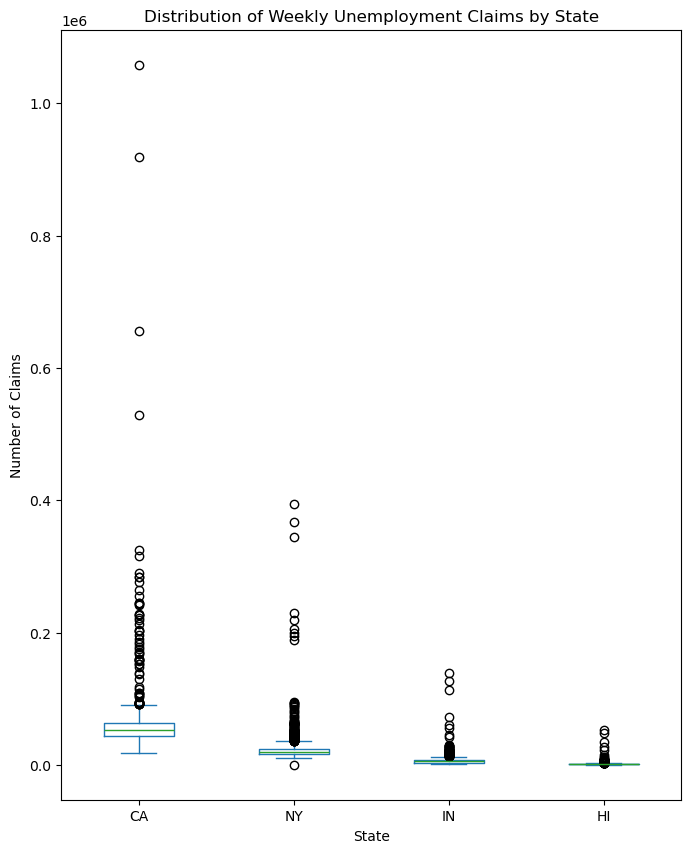

In [62]:
## Setting up a basic dataframe object to work with
df_all = pd.concat([claims_dfs[code]["Claims"] for code in datasets],axis=1)
df_all.columns = ["CA", "NY", "IN", "HI"]

## Boxplot for distribution of weekly unemployment claims per state
df_all.plot(kind="box", figsize=(8,10))
plt.title("Distribution of Weekly Unemployment Claims by State")
plt.ylabel("Number of Claims")
plt.xlabel("State")
plt.show()

The summary statistics for df_all show the distribution of weekly unemployment claims by state. California has the highest median and maximum number of unemployment claims, and also has the widest spread and the highest outliers. But California's large number of unemployment claims makes it difficult to see the plots for other graphs. Let's graph these plots on a log scale, as seen below!

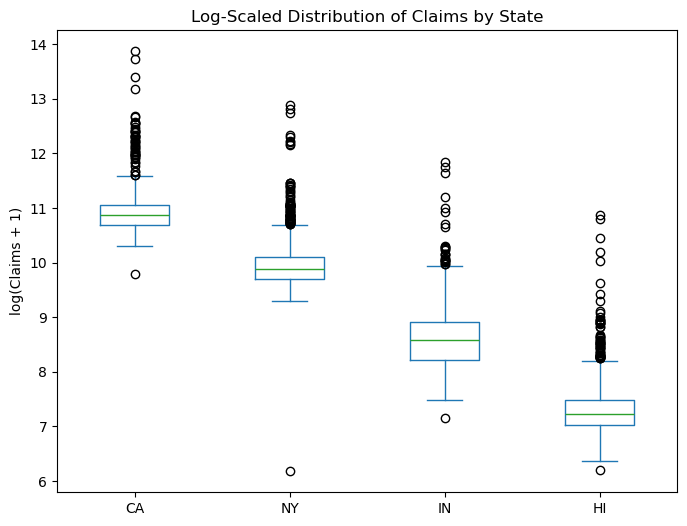

In [63]:
## Log scale
df_all_log = np.log1p(df_all)
df_all_log.plot(kind="box", figsize=(8,6))

## Setting up plot
plt.title("Log-Scaled Distribution of Claims by State")
plt.ylabel("log(Claims + 1)")
plt.show()

California dominates due to much higher absolute claim counts, but the log scale reveals underlying distribution patterns more clearly. Some states show slightly wider boxes and longer whiskers, showing greater relative volatility in claims. Outliers still remain after log-scaling, highlighting extreme economic shocks on a macro scale (ex. COVID-19 pandemic).

In [64]:
df_all.dtypes

CA    float64
NY    float64
IN    float64
HI    float64
dtype: object

The number of claims for each state is a float, which means it can be easily manipulated for computations (and is a good thing!)

## **7. Producing Summary Statistics**

Here, we work to produce summary statistics, those of which are useful as they provide us with a scope of the basic scale of claims existing in each state. Prior to any analysis, we naturally expect states like California and New York to have much larger claims as compared to Hawaii and Indiana, as the latter states have much smaller labor markets. 

**Code cell purpose:** Below, we have a cell which calculates relevant summary statistics per state, including spread, raw missing counts, etc. 

In [9]:
## Simply getting summary statistics
summary_stats = (
    combined_claims
    .groupby("State")
    .agg(
        observations=("Claims", "size"),
        raw_missing_claims=("Claims_Was_Missing", "sum"),
        mean_claims=("Claims", "mean"),
        median_claims=("Claims", "median"),
        sd_claims=("Claims", "std"),
        min_claims=("Claims", "min"),
        p25_claims=("Claims", lambda x: x.quantile(0.25)),
        p75_claims=("Claims", lambda x: x.quantile(0.75)),
        max_claims=("Claims", "max")
    )
    .reset_index()
)

## Adding a coefficient of variation to compare the volatility across differently sized states
summary_stats["cv_claims"] = summary_stats["sd_claims"] / summary_stats["mean_claims"]

## Displaying
display(summary_stats.round(2))

,State,observations,raw_missing_claims,mean_claims,median_claims,sd_claims,min_claims,p25_claims,p75_claims,max_claims,cv_claims
0,California,2097,5,"58,606.31","52,384.00","42,137.74","18,046.00","44,001.00","63,122.00","1,058,325.00",0.72
1,Hawaii,2141,48,"1,673.52","1,385.00","2,028.86",495.00,"1,118.00","1,790.00","53,102.00",1.21
2,Indiana,2096,0,"6,547.56","5,379.00","6,415.86","1,279.00","3,685.75","7,384.50","139,174.00",0.98
3,New York,2096,0,"22,871.85","19,493.50","19,048.16",481.00,"16,377.50","24,292.75","394,701.00",0.83


## **8. Analyzing Annual Trends**

Here, we look at an annual summary for each of the state's claims, that of which provides good insight into how the average and maximum claims have changed progressively. What is most helpful to pull from these results include data for years close to recession periods/the COVID spike, helping us with later model design/validation below!

**Code cell purpose:** Below, we have a cell which summarizes the claims data per year for each state, helping reveal certain long-term trends. 

In [10]:
## Generating the annual summary
annual_summary = (
    combined_claims
    .groupby(["State", "Year"])
    .agg(
        avg_claims=("Claims", "mean"),
        total_claims=("Claims", "sum"),
        max_claims=("Claims", "max"),
        weeks_observed=("Claims", "size")
    )
    .reset_index()
)

## Displaying most recent years first as these are the most relevant for forecasting
display(annual_summary.sort_values(["State", "Year"], ascending=[True, False]).head(20).round(2))

## Also displaying the COVID peak year directly for report-writing and insight purposes
covid_year_summary = annual_summary.loc[annual_summary["Year"].between(2019, 2021)]
display(covid_year_summary.sort_values(["State", "Year"]).round(2))

,State,Year,avg_claims,total_claims,max_claims,weeks_observed
40,California,2026,"43,231.33","648,470.00","55,731.00",15
39,California,2025,"43,392.56","2,256,413.00","59,969.00",52
38,California,2024,"43,437.54","2,258,752.00","52,368.00",52
37,California,2023,"44,741.08","2,326,536.00","63,697.00",52
36,California,2022,"43,004.45","2,279,236.00","62,274.00",53
35,California,2021,"76,080.29","3,956,175.00","182,625.00",52
34,California,2020,"221,880.15","11,537,768.00","1,058,325.00",52
33,California,2019,"40,371.40","2,099,313.00","56,886.00",52
32,California,2018,"40,750.71","2,119,037.00","58,962.00",52
31,California,2017,"43,307.54","2,251,992.00","61,914.00",52


,State,Year,avg_claims,total_claims,max_claims,weeks_observed
33,California,2019,"40,371.40","2,099,313.00","56,886.00",52
34,California,2020,"221,880.15","11,537,768.00","1,058,325.00",52
35,California,2021,"76,080.29","3,956,175.00","182,625.00",52
75,Hawaii,2019,"1,187.52","61,751.00","1,903.00",52
76,Hawaii,2020,"8,376.58","435,582.00","53,102.00",52
77,Hawaii,2021,"2,694.88","140,134.00","5,598.00",52
116,Indiana,2019,"2,635.83","137,063.00","4,835.00",52
117,Indiana,2020,"24,371.67","1,267,327.00","139,174.00",52
118,Indiana,2021,"7,606.96","395,562.00","17,724.00",52
157,New York,2019,"15,844.73","823,926.00","45,065.00",52


## **9. Generating Time-Series Plots by State**

Here, we generate time-series plots for each state, with the first plot showcasing each state separately (do not want California's large scale taking over visualization of smaller states). The second plot has all states overlaid in levels, allowing us to compare timing of spikes!

**Code cell purpose:** Here, we have both separated and overlaid visualizations of time siries for the states. Directly below is separate.

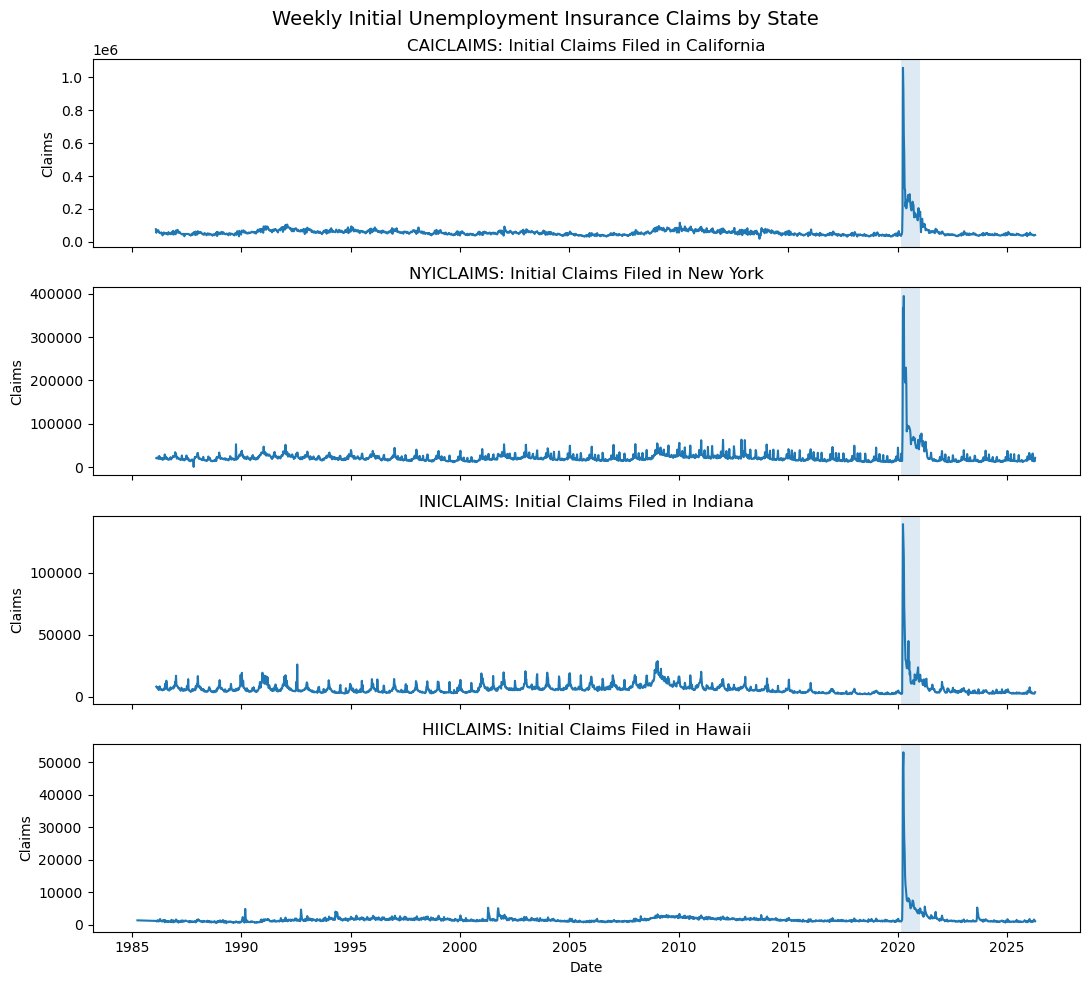

In [11]:
## Setting figure specifications
fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)

## Generating the figures
for ax, code in zip(axes, datasets):
    df = claims_dfs[code]
    ax.plot(df["Date"], df["Claims"])
    ax.set_title(f"{code}: Initial Claims Filed in {state_names[code]}")
    ax.set_ylabel("Claims")
    
    ## Marking the early COVID period as it is the largest structural break in the series, important!
    ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-01-01"), alpha=0.15)

axes[-1].set_xlabel("Date")
fig.suptitle("Weekly Initial Unemployment Insurance Claims by State", fontsize=14)
plt.tight_layout()
plt.show();


**Code cell purpose:** Directly below is overlaid.


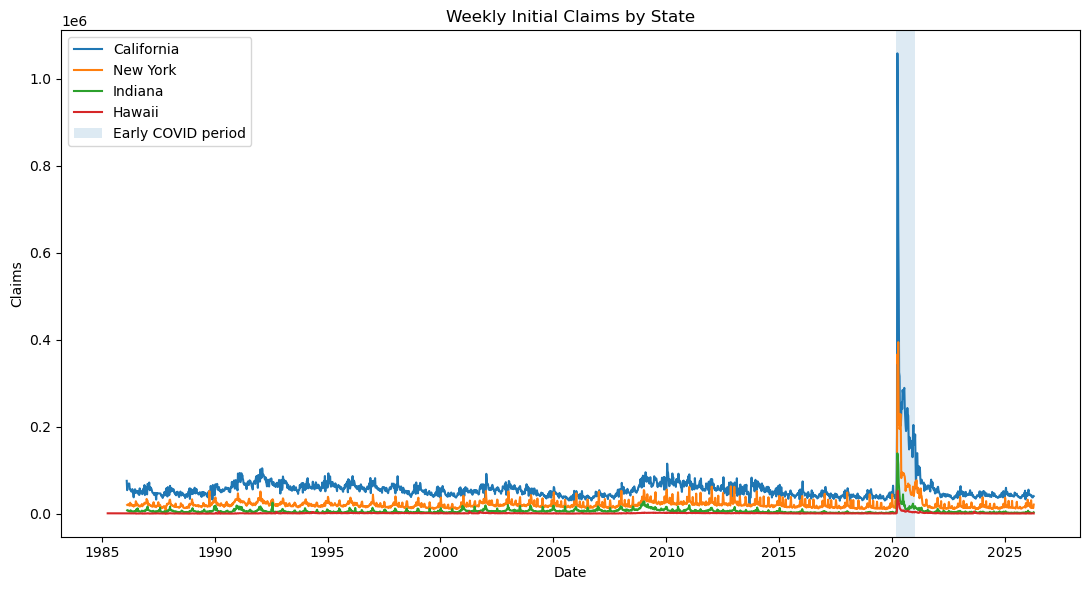

In [12]:
## Setting figure specifications
fig, ax = plt.subplots(figsize=(11, 6))

## Generating the figures
for code in datasets:
    df = claims_dfs[code]
    ax.plot(df["Date"], df["Claims"], label=state_names[code])

ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-01-01"), alpha=0.15, label="Early COVID period")
ax.set_xlabel("Date")
ax.set_ylabel("Claims")
ax.set_title("Weekly Initial Claims by State")
ax.legend()
plt.tight_layout()
plt.show();


**Code cell purpose:** Here, we have a visualization in which we can clearly see times of recessions shaded!

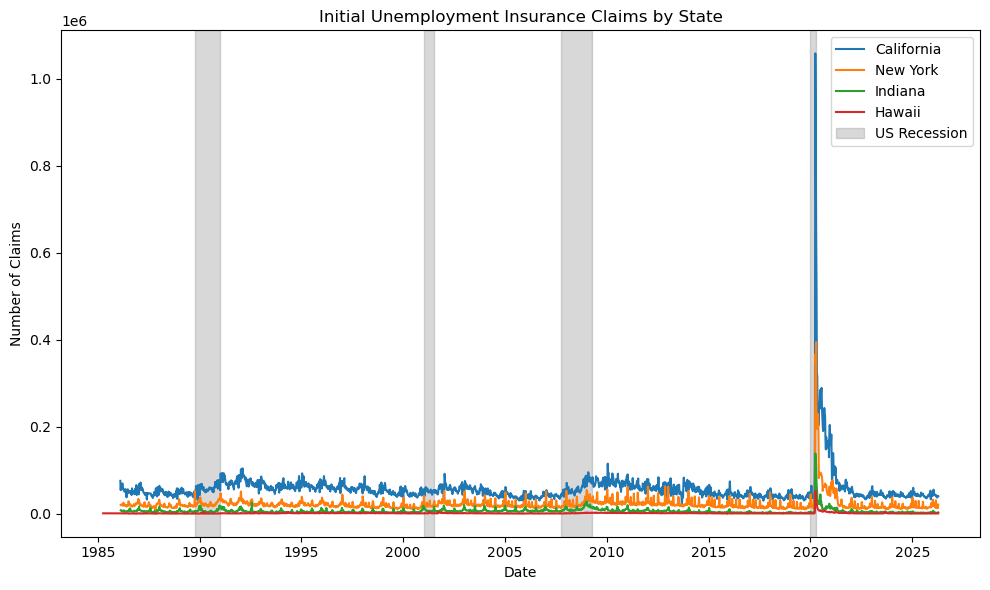

In [58]:
## Looking at distinct visualization of recessions shaded

recessions = pd.read_csv("Data/JHDUSRGDPBR.csv")
recessions["observation_date"] = pd.to_datetime(recessions["observation_date"])

## Setting the recession dataset to use dates as its index
recessions = recessions.set_index("observation_date")

## Getting the full date range from the claims data using the Date column, not the row index
start_date = min(claims_dfs[code]["Date"].min() for code in datasets)
end_date = max(claims_dfs[code]["Date"].max() for code in datasets)

## Keeping only recession data within the claims sample period
recessions = recessions.loc[start_date:end_date]

fig, ax = plt.subplots(figsize=(10, 6))

## Plotting weekly initial claims for each state
for code in datasets:
    df = claims_dfs[code]
    ax.plot(df["Date"], df["Claims"], label=state_names[code])

## Shading weeks/months classified as US recession periods
ax.fill_between(
    recessions.index,
    0,
    1,
    where=recessions["JHDUSRGDPBR"] == 1,
    color="gray",
    alpha=0.3,
    transform=ax.get_xaxis_transform(),
    label="US Recession"
)

## Formatting the figure
ax.set_title("Initial Unemployment Insurance Claims by State")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Claims")
ax.legend()
plt.tight_layout()
plt.show()

## **10. Having Indexed Comparison Across States**

Each of the states has varied population sizes which are not directly comparable. Therefore, simply comparing raw claims would not be beneficial. Instead, we have an indexed plot which sets each state's first observed week equivalent to 100, such that the graph makes comparisons of relative changes rather than raw levels.

**Code cell purpose:** Below, we have a cell generating indexed claims such that states with varied baseline levels can still be directly compared on similar scales. 

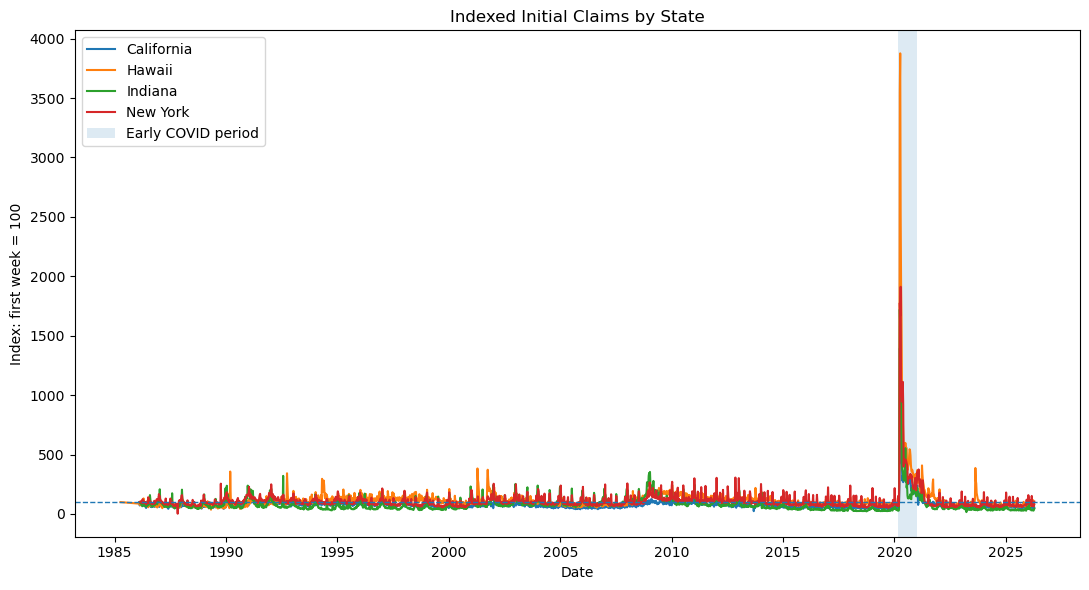

In [13]:
## Generating the indexed claims below
indexed_claims = combined_claims.copy()
indexed_claims["Claims_Index"] = (
    indexed_claims
    .groupby("State")["Claims"]
    .transform(lambda x: 100 * x / x.iloc[0])
)

## Setting up figure
fig, ax = plt.subplots(figsize=(11, 6))

## Actually plotting!
for state, df in indexed_claims.groupby("State"):
    ax.plot(df["Date"], df["Claims_Index"], label=state)

ax.axhline(100, linestyle="--", linewidth=1)
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-01-01"), alpha=0.15, label="Early COVID period")
ax.set_xlabel("Date")
ax.set_ylabel("Index: first week = 100")
ax.set_title("Indexed Initial Claims by State")
ax.legend()
plt.tight_layout()
plt.show();


## **11. Reviewing the Distribution and Checking Outliers**

Here, we felt it useful to have histograms generated that let us see the distribution of weekly claims for each state. In doing so, we can see things like heavy large right tails, something that checks out with basic sanity as unemployment claims tend to spike during recessions and times of stress like COVID (so occasionally we see singular major rises!). Understanding these spikes is important so we are not confused later when modeling.

**Code cell purpose:** Below, the cell generates visualizations for each state's claims distribution, showcasing potential skews.


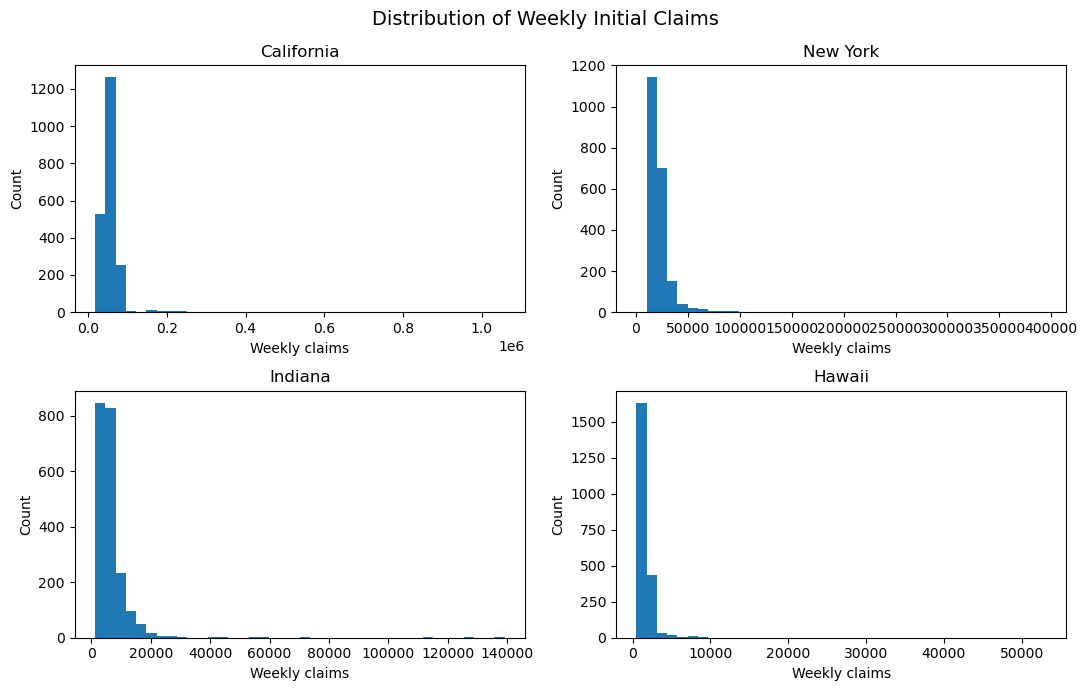

In [14]:
## Setting up the figure
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.flatten()

## Generating plot
for ax, code in zip(axes, datasets):
    df = claims_dfs[code]
    ax.hist(df["Claims"], bins=40)
    ax.set_title(state_names[code])
    ax.set_xlabel("Weekly claims")
    ax.set_ylabel("Count")

fig.suptitle("Distribution of Weekly Initial Claims", fontsize=14)
plt.tight_layout()
plt.show();


## **12. Looking Into the Largest Weekly Claims Observations**

As the above distributions have a pretty distinct right-skew, we felt it important to directly identify the weeks with biggest claims for each state. Again, such rows are not problem rows or errors, per say, instead corresponding to things like recessions or COVID shocks. Again, this helps us begin thinking about how to approach structural breaks!

**Code cell purpose:** Cell below works to identify largest weekly claims observations in each state, separation between data errors from actual shocks. 

In [15]:
## Determining largest claims
top_claim_weeks = (
    combined_claims
    .sort_values("Claims", ascending=False)
    .loc[:, ["State", "StateCode", "Date", "Claims", "Year"]]
    .head(50)
)

## Displaying, and seeing that years tend to be COVID times and other recession periods!
display(top_claim_weeks)

,State,StateCode,Date,Claims,Year
1781,California,CAICLAIMS,2020-03-28,"1,058,325.00",2020
1782,California,CAICLAIMS,2020-04-04,"918,814.00",2020
1783,California,CAICLAIMS,2020-04-11,"655,472.00",2020
1784,California,CAICLAIMS,2020-04-18,"528,360.00",2020
3879,New York,NYICLAIMS,2020-04-11,"394,701.00",2020
3877,New York,NYICLAIMS,2020-03-28,"366,595.00",2020
3878,New York,NYICLAIMS,2020-04-04,"344,451.00",2020
1785,California,CAICLAIMS,2020-04-25,"325,343.00",2020
1786,California,CAICLAIMS,2020-05-02,"316,257.00",2020
1797,California,CAICLAIMS,2020-07-18,"289,594.00",2020


## **13. Looking at Rolling-Average Trends**

By looking at rolling average over 52 weeks rather than individual gaps, we can smooth out minor moments of volatility and instead look at where there are major changes in the long-run. Mainly for building understanding of the data we have prior to intense forecasting.

**Code cell purpose:** Cell below computes and plots 52-week rolling averages for each state, smoothing weekly volatility prior to modeling.


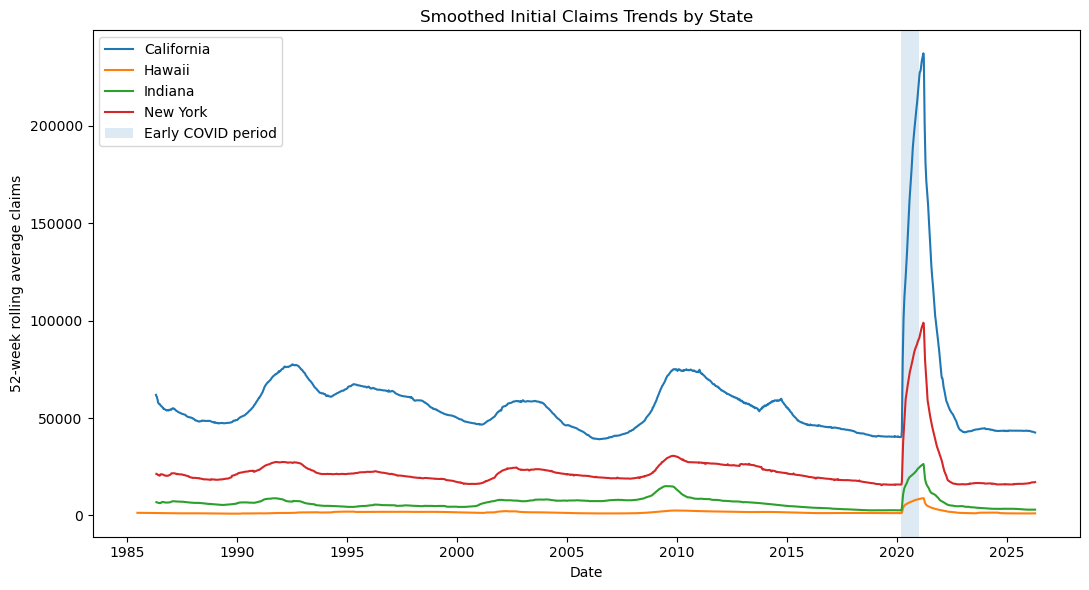

In [16]:
## Generating rolling claims
rolling_claims = combined_claims.sort_values(["State", "Date"]).copy()
rolling_claims["Claims_52wk_MA"] = (
    rolling_claims
    .groupby("State")["Claims"]
    .transform(lambda x: x.rolling(window=52, min_periods=12).mean())
)

## Setting up figure
fig, ax = plt.subplots(figsize=(11, 6))

## Plotting!
for state, df in rolling_claims.groupby("State"):
    ax.plot(df["Date"], df["Claims_52wk_MA"], label=state)

ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-01-01"), alpha=0.15, label="Early COVID period")
ax.set_xlabel("Date")
ax.set_ylabel("52-week rolling average claims")
ax.set_title("Smoothed Initial Claims Trends by State")
ax.legend()
plt.tight_layout()
plt.show();


## **14. Major Takeaways to Carry Forward**

- We see that there are some missing values for states like Hawaii which needed to be interpolated. Details about process/logic in report
- No issue of duplicate, negative, or oddly-gapped claims data
- Clear difference in the level of claims for each state, matches with basic logic of larger states with larger labor markets have larger claims levels
- Understanding of spikes during shocks like COVID, periods of recession, etc. do appear quite clearly, basic logic checks out here

# **CAICLAIMS Model Testing - Determining Model Efficacy Prior to Scaling**

This entire section works with California data as the initial example for forecasting, prior to scaling up to all of the four states we have. We utilized the final two years of data as a test set, fitting a basic/plain ARIMA baseline, and afterwards adding SARIMAX specifications with Fourier seasonality and COVID indicators (dealing with the structural break!). RMSE is utilized as a measure of out-of-sample prediction accuracy, and we additionally have AIC/BIC as model-selection diagnositcs. 

## **1. ARIMA Baseline Model**

**Code cell purpose:** The cell below generates the California modeling series, additionally defining the training and two-year holdout test periods.

Training period: 1986-02-08 to 2024-04-13 (1,993 weeks)
Testing period: 2024-04-20 to 2026-04-11 (104 weeks)


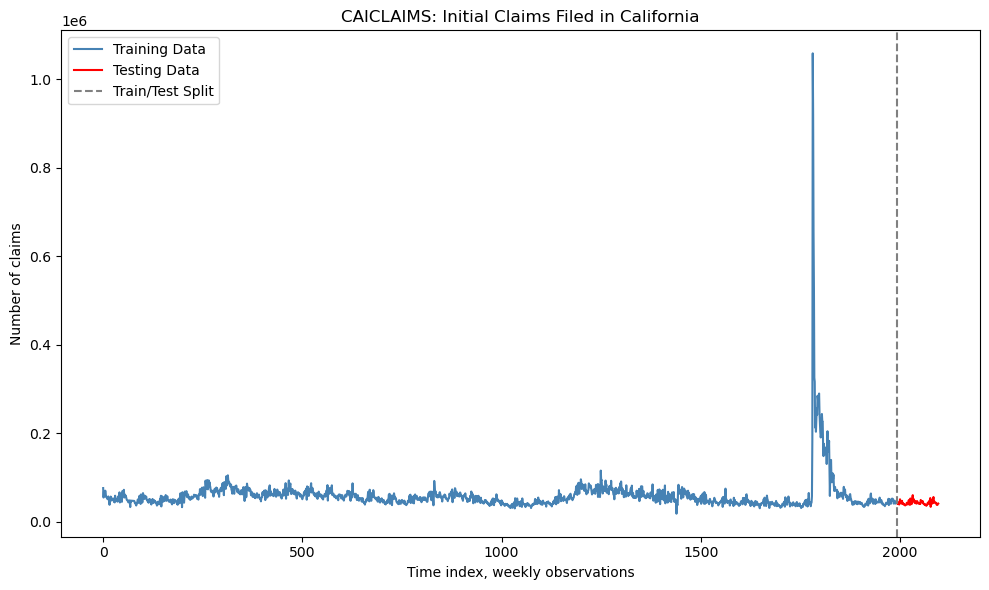

In [17]:
## Choosing just California
y_CA = claims_dfs["CAICLAIMS"]["Claims"].reset_index(drop=True)
date_CA = claims_dfs["CAICLAIMS"]["Date"].reset_index(drop=True)

## Separating the test set
test_horizon = 104  ## final 2 years
train_end = len(y_CA) - test_horizon

## Numeric time indexes are kept because the original modeling code was built around them
ttrain = np.arange(train_end)
ttest = np.arange(train_end, len(y_CA))
tpred = np.arange(train_end, len(y_CA) + test_horizon)  ## testing period plus 2-year future forecast

## Training modeling
ytrain_CA = y_CA.iloc[:train_end]
ytest_CA = y_CA.iloc[train_end:]

train_start_date = date_CA.iloc[0]
train_end_date = date_CA.iloc[train_end - 1]
test_start_date = date_CA.iloc[train_end]
test_end_date = date_CA.iloc[-1]

## Setting up the figures
print(f"Training period: {train_start_date.date()} to {train_end_date.date()} ({len(ytrain_CA):,} weeks)")
print(f"Testing period: {test_start_date.date()} to {test_end_date.date()} ({len(ytest_CA):,} weeks)")

plt.figure(figsize=(10, 6))
plt.plot(ttrain, ytrain_CA, label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Testing Data", color="red")
plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split")
plt.title("CAICLAIMS: Initial Claims Filed in California")
plt.xlabel("Time index, weekly observations")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();

### **Analysis of the Training Data Time Series**

**Code cell purpose:** Below, we have a cell which plots ACF and PACF of training level series, allowing us to inspect persistence prior to actual ARIMA modeling.

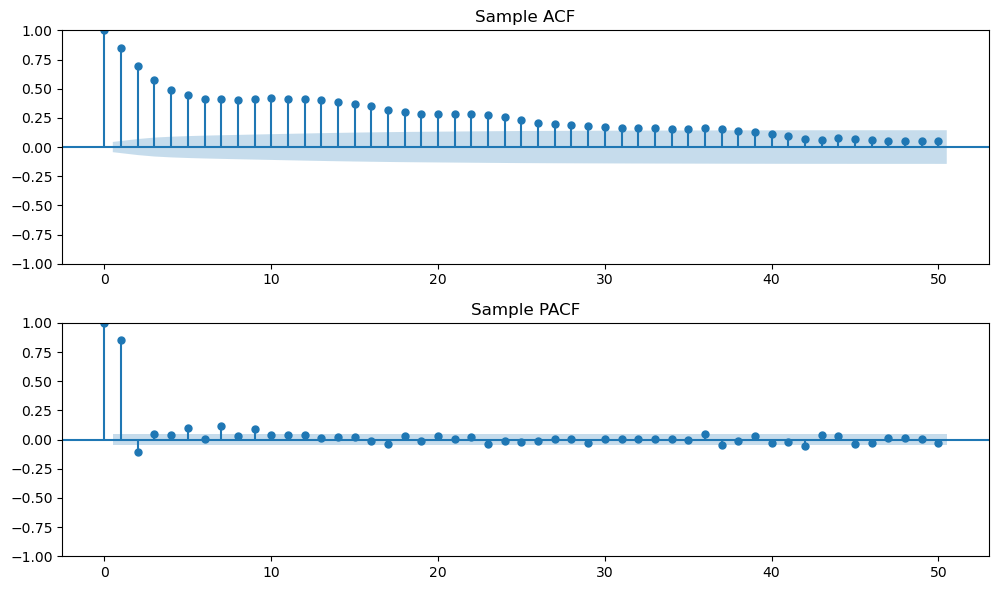

In [18]:
## Setting p_max
p_max = 50

## ACF/PACF on the level series helps show persistence before differencing
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(ytrain_CA.dropna(), lags=p_max, ax=ax1, title="Sample ACF")
plot_pacf(ytrain_CA.dropna(), lags=p_max, ax=ax2, title="Sample PACF")
plt.tight_layout()
plt.show();

**Code cell purpose:** Cell below completes differencing of training series and plots weekly changes, allowing us to asses whether differencing actualy improves stationarity. 

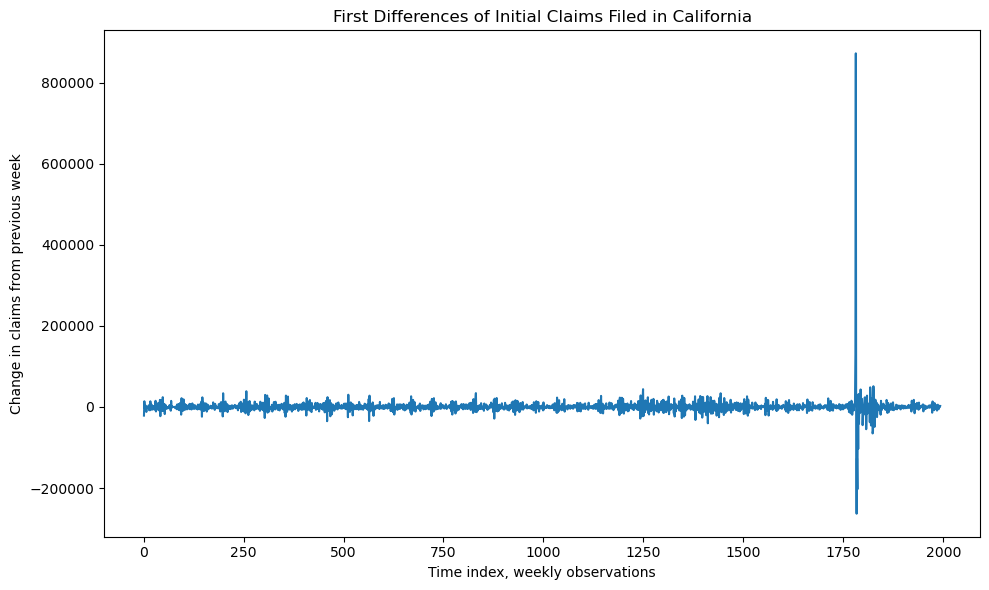

In [19]:
## Differenced training set
ytrain_CA_diff = ytrain_CA.diff()

## First differences removes much of the slow-moving trend and help ARIMA with non-stationarity!
plt.figure(figsize=(10,6))
plt.plot(ytrain_CA_diff.dropna())
plt.xlabel("Time index, weekly observations")
plt.ylabel("Change in claims from previous week")
plt.title("First Differences of Initial Claims Filed in California")
plt.tight_layout()
plt.show();

**Code cell purpose:** Cell below plots the ACF/PACF of differenced series, again for ARIMA order choice logic. 

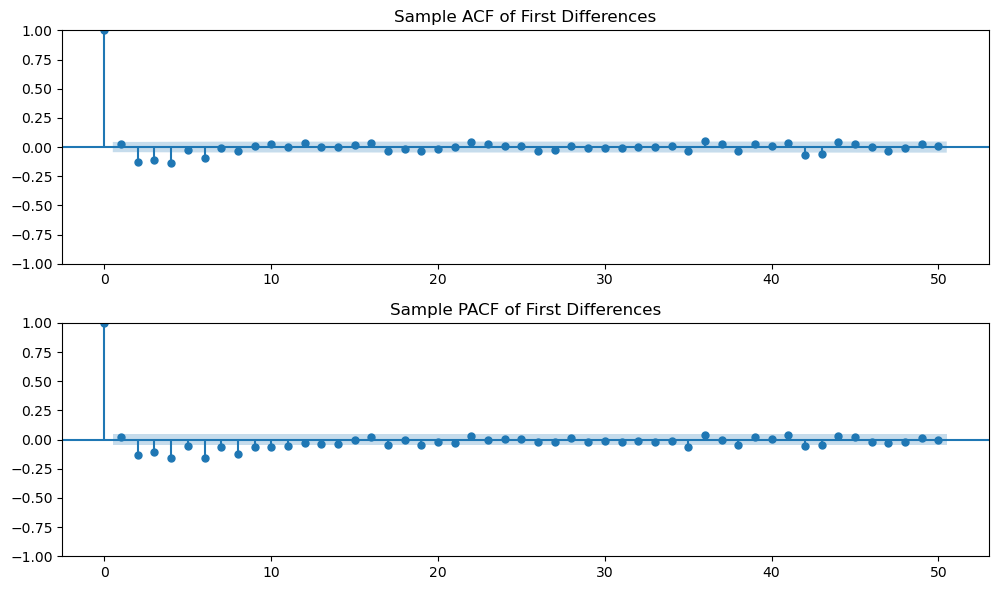

In [20]:
## Setting p_max
p_max = 50

## ACF/PACF after the differencing gives us a practical guide for candidate AR and MA orders
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
plot_acf(ytrain_CA_diff.dropna(), lags=p_max, ax=ax1, title="Sample ACF of First Differences")
plot_pacf(ytrain_CA_diff.dropna(), lags=p_max, ax=ax2, title="Sample PACF of First Differences")
plt.tight_layout()
plt.show();

### **Checking Stationarity**

Utilizing the ADF to formally check for a unit root (which would make our time series non-stationary!). Basically, this is to inform our decision to potentially include the parameter of "d = 1" in later ARIMA/SARIMAX grid work when we have a very prevalent level series.

**Code cell purpose:** Cell below runs ADF tests on level and differenced training series, want to justify choice of differencing. 

In [21]:
## Brief function for ADF work
def adf_summary(series, label):
    clean_series = pd.Series(series).dropna()
    stat, pvalue, used_lag, nobs, crit_vals, _ = adfuller(clean_series, autolag="AIC")
    return {
        "series": label, "adf_statistic": stat, "p_value": pvalue,
        "used_lag": used_lag, "n_obs": nobs,
        "critical_value_5pct": crit_vals["5%"]
    }

## Getting the ADF results
adf_results = pd.DataFrame([
    adf_summary(ytrain_CA, "CA claims, levels"),
    adf_summary(ytrain_CA_diff, "CA claims, first differences")
])

display(adf_results.round(4))


,series,adf_statistic,p_value,used_lag,n_obs,critical_value_5pct
0,"CA claims, levels",-6.15,0.00,11,1981,-2.86
1,"CA claims, first differences",-14.23,0.00,18,1973,-2.86


### **Parameter Selection (Grid Search)**

**Code cell purpose:** Below cell works to define ARIMA grid-search helper, function is brief and only goal is to return AIC, BIC, and holdout RMSE here! 

In [22]:
## Setting parameters
pmax, dmax, qmax = 8, 1, 6

## Defining the ARIMA fitting function with parameters
def fit_arima(params):
    p, d, q = map(int, params)
    try:
        model = ARIMA(ytrain_CA, order=(p, d, q)).fit()
        yhat = model.get_forecast(steps=len(ytest_CA)).predicted_mean
        yhat.index = ytest_CA.index
        rmse = np.sqrt(mean_squared_error(ytest_CA, yhat))
        return {"p": p, "d": d, "q": q, "AIC": model.aic, "BIC": model.bic, "RMSE": rmse}
    except Exception:
        return None


**Code cell purpose:** Cell below actually runs/loads ARIMA grid search, gives best candidate models based on the holdout RMSE. 

In [23]:
## Setting distinct path
cache_path_arima = "arima_grid_results_CAICLAIMS.csv"

## Building grid for parameter
param_grid = list(itertools.product(
    range(pmax + 1),
    range(dmax + 1),
    range(qmax + 1)
))

## Necessary columns
required_arima_cols = {"p", "d", "q", "AIC", "BIC", "RMSE"}

## Working through the process! Detailed steps below
if os.path.exists(cache_path_arima):
    print(f"Loading cached ARIMA grid search results from {cache_path_arima}")
    results_arima_df = pd.read_csv(cache_path_arima)

    ## Re-run if the cache is not in the expected format
    if not required_arima_cols.issubset(results_arima_df.columns):
        print("The cached ARIMA results are missing required columns, so the grid search needs to be run again.")
        results_arima_df = pd.DataFrame()

else:
    results_arima_df = pd.DataFrame()

if results_arima_df.empty:
    print("Running ARIMA grid search!")

    results_arima = Parallel(n_jobs=-1, verbose=10)(
        delayed(fit_arima)(params) for params in param_grid
    )

    results_arima = [r for r in results_arima if r is not None]
    results_arima_df = pd.DataFrame(results_arima)

    if results_arima_df.empty:
        raise ValueError("ARIMA grid search failed, meaning no models were successfully fit!")

    results_arima_df.to_csv(cache_path_arima, index=False)
    print(f"Saved ARIMA grid search results to {cache_path_arima}")

## Showing the best few models by holdout RMSE for transparency
display(results_arima_df.sort_values("RMSE").head(10).round(3))

Loading cached ARIMA grid search results from arima_grid_results_CAICLAIMS.csv


,p,d,q,AIC,BIC,RMSE
119,8,1,0,"45,577.51","45,627.88","4,599.13"
63,4,1,0,"45,662.47","45,690.45","4,602.98"
77,5,1,0,"45,658.34","45,691.92","4,621.72"
105,7,1,0,"45,604.59","45,649.36","4,635.10"
91,6,1,0,"45,609.98","45,649.16","4,664.12"
10,0,1,3,"45,644.79","45,667.18","4,681.73"
9,0,1,2,"45,710.97","45,727.76","4,682.99"
49,3,1,0,"45,709.97","45,732.36","4,688.87"
11,0,1,4,"45,560.18","45,588.16","4,756.92"
37,2,1,2,"45,571.39","45,599.37","4,764.09"


### **Determining the Best Models by Evaluation Metrics**

**Code cell purpose:** Cell below extracts the best ARIMA specifications as according to our three desired metrics of AIC, BIC, and holdout RMSE.

In [24]:
## Getting best values
best_aic = results_arima_df.loc[results_arima_df["AIC"].idxmin()]
best_bic = results_arima_df.loc[results_arima_df["BIC"].idxmin()]
best_rmse = results_arima_df.loc[results_arima_df["RMSE"].idxmin()]

## Printing it out legibly below
print(
    f"Best model by AIC: ARIMA({int(best_aic['p'])}, {int(best_aic['d'])}, {int(best_aic['q'])}), "
    f"AIC: {best_aic['AIC']:.3f}, BIC: {best_aic['BIC']:.3f}, RMSE: {best_aic['RMSE']:.3f}"
)

print(
    f"Best model by BIC: ARIMA({int(best_bic['p'])}, {int(best_bic['d'])}, {int(best_bic['q'])}), "
    f"AIC: {best_bic['AIC']:.3f}, BIC: {best_bic['BIC']:.3f}, RMSE: {best_bic['RMSE']:.3f}"
)

print(
    f"Best model by RMSE: ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}), "
    f"AIC: {best_rmse['AIC']:.3f}, BIC: {best_rmse['BIC']:.3f}, RMSE: {best_rmse['RMSE']:.3f}"
)

Best model by AIC: ARIMA(6, 0, 4), AIC: 45543.513, BIC: 45610.682, RMSE: 14433.620
Best model by BIC: ARIMA(0, 1, 6), AIC: 45545.010, BIC: 45584.189, RMSE: 4809.309
Best model by RMSE: ARIMA(8, 1, 0), AIC: 45577.506, BIC: 45627.878, RMSE: 4599.134


**Code cell purpose:** Cell below completes fitting of ARIMA model selected using AIC, prints out summary.

In [25]:
## Getting the AIC summary results!
best_aic_model = ARIMA(
    ytrain_CA,
    order=(int(best_aic["p"]), int(best_aic["d"]), int(best_aic["q"]))
).fit()

print(best_aic_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1993
Model:                 ARIMA(6, 0, 4)   Log Likelihood              -22759.757
Date:                Fri, 01 May 2026   AIC                          45543.513
Time:                        01:13:31   BIC                          45610.682
Sample:                             0   HQIC                         45568.180
                               - 1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.942e+04   1.18e+04      5.020      0.000    3.62e+04    8.26e+04
ar.L1          0.4586      0.182      2.518      0.012       0.102       0.816
ar.L2          1.5480      0.060     25.873      0.0

**Code cell purpose:** Cell below completes fitting of ARIMA model selected using BIC, prints out summary.


In [26]:
## Getting the BIC summary results!
best_bic_model = ARIMA(
    ytrain_CA,
    order=(int(best_bic["p"]), int(best_bic["d"]), int(best_bic["q"]))
).fit()

print(best_bic_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1993
Model:                 ARIMA(0, 1, 6)   Log Likelihood              -22765.505
Date:                Fri, 01 May 2026   AIC                          45545.010
Time:                        01:13:32   BIC                          45584.189
Sample:                             0   HQIC                         45559.399
                               - 1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0635      0.005    -13.003      0.000      -0.073      -0.054
ma.L2         -0.2219      0.012    -17.911      0.000      -0.246      -0.198
ma.L3         -0.1540      0.029     -5.395      0.0

**Code cell purpose.** Cell below completes fitting of ARIMA model selected using holdout RMSE, prints out summary.


In [27]:
## Getting the RMSE summary results!
best_rmse_model = ARIMA(
    ytrain_CA,
    order=(int(best_rmse["p"]), int(best_rmse["d"]), int(best_rmse["q"]))
).fit()

print(best_rmse_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1993
Model:                 ARIMA(8, 1, 0)   Log Likelihood              -22779.753
Date:                Fri, 01 May 2026   AIC                          45577.506
Time:                        01:13:35   BIC                          45627.878
Sample:                             0   HQIC                         45596.005
                               - 1993                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0415      0.004    -10.140      0.000      -0.050      -0.033
ar.L2         -0.2007      0.010    -20.251      0.000      -0.220      -0.181
ar.L3         -0.1481      0.042     -3.536      0.0

### **Plotted ARIMA Predictions**

**Code cell purpose:** Cell below performs forecasting with selected ARIMA models, additionally plotting their predictions against holdout data. 

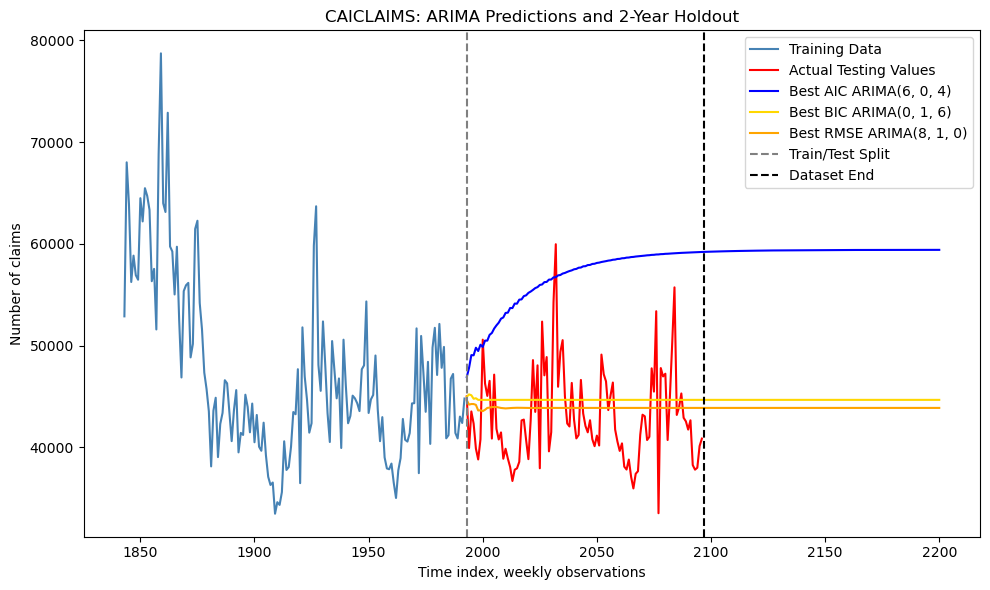

Root Mean Squared Error of Best AIC ARIMA(6, 0, 4) Model: 14433.620
Root Mean Squared Error of Best BIC ARIMA(0, 1, 6) Model: 4809.309
Root Mean Squared Error of Best RMSE ARIMA(8, 1, 0) Model: 4599.134


In [28]:
## Best results from AIC
best_aic_fcast = best_aic_model.get_prediction(start=train_end, end=len(y_CA) + test_horizon - 1)
best_aic_yhat = best_aic_fcast.predicted_mean
best_aic_rmse = np.sqrt(mean_squared_error(ytest_CA, best_aic_yhat.iloc[:len(ytest_CA)]))

## Best results from BIC
best_bic_fcast = best_bic_model.get_prediction(start=train_end, end=len(y_CA) + test_horizon - 1)
best_bic_yhat = best_bic_fcast.predicted_mean
best_bic_rmse = np.sqrt(mean_squared_error(ytest_CA, best_bic_yhat.iloc[:len(ytest_CA)]))

## Best results from holdout RMSE
best_rmse_fcast = best_rmse_model.get_prediction(start=train_end, end=len(y_CA) + test_horizon - 1)
best_rmse_yhat = best_rmse_fcast.predicted_mean
best_rmse_rmse = np.sqrt(mean_squared_error(ytest_CA, best_rmse_yhat.iloc[:len(ytest_CA)]))

## Getting the figures/plots set up
plt.figure(figsize=(10,6))
plt.plot(ttrain[(train_end - 150):], ytrain_CA.iloc[(train_end - 150):], color="steelblue", label="Training Data")
plt.plot(ttest, ytest_CA, color="red", label="Actual Testing Values")

plt.plot(tpred, best_aic_yhat, color="blue", 
         label=f"Best AIC ARIMA({int(best_aic['p'])}, {int(best_aic['d'])}, {int(best_aic['q'])})")
plt.plot(tpred, best_bic_yhat, color="gold", 
         label=f"Best BIC ARIMA({int(best_bic['p'])}, {int(best_bic['d'])}, {int(best_bic['q'])})")
plt.plot(tpred, best_rmse_yhat, color="orange", 
         label=f"Best RMSE ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])})")

plt.axvline(x=train_end, color="grey", linestyle="--", label="Train/Test Split")
plt.axvline(x=len(y_CA), color="black", linestyle="--", label="Dataset End")

plt.xlabel("Time index, weekly observations")
plt.ylabel("Number of claims")
plt.title("CAICLAIMS: ARIMA Predictions and 2-Year Holdout")
plt.legend(); plt.tight_layout(); plt.show();

print(f"Root Mean Squared Error of Best AIC ARIMA({int(best_aic['p'])}, {int(best_aic['d'])}, {int(best_aic['q'])}) Model: {best_aic_rmse:.3f}")
print(f"Root Mean Squared Error of Best BIC ARIMA({int(best_bic['p'])}, {int(best_bic['d'])}, {int(best_bic['q'])}) Model: {best_bic_rmse:.3f}")
print(f"Root Mean Squared Error of Best RMSE ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) Model: {best_rmse_rmse:.3f}")

## **2. SARIMAX with Fourier Frequencies, Before/After COVID Dummy**

**Code cell purpose:** Cell below plots entire California split between train and test, allows forecasting setup to be clear visually. 

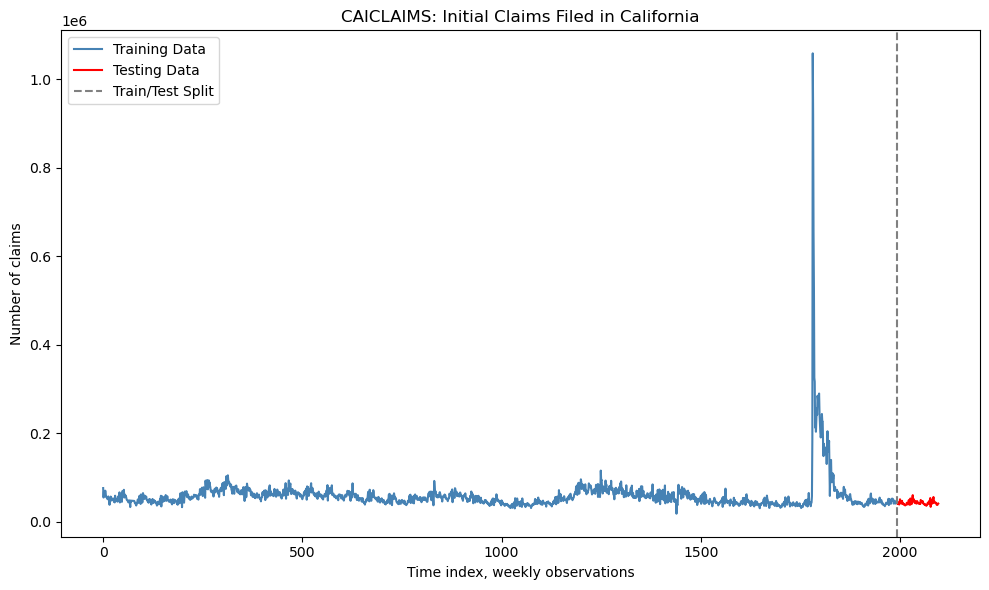

In [29]:
## Plotting everything!
plt.figure(figsize=(10, 6))
plt.plot(ttrain, ytrain_CA, label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Testing Data", color="red")
plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split")
plt.title("CAICLAIMS: Initial Claims Filed in California")
plt.xlabel("Time index, weekly observations")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();

**Code cell purpose:** Cell below re-plots the first differences prior to SARIMAX section, meant to keep model diagnostic close to the model code. 

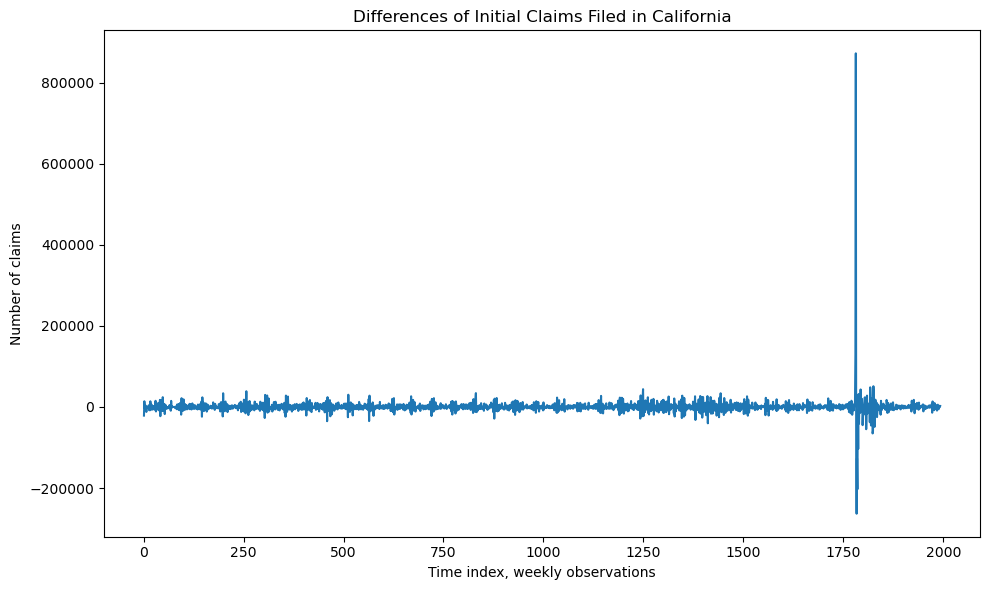

In [30]:
## Plotting it!
plt.figure(figsize=(10,6))
plt.plot(ytrain_CA_diff.dropna())
plt.xlabel("Time index, weekly observations")
plt.ylabel("Number of claims")
plt.title("Differences of Initial Claims Filed in California")
plt.tight_layout()
plt.show();

### **Design Matrix Construction**

**Code cell purpose:** Cell below has function to briefly define exogenous SARIMAX features, specifically Fourier seasonality, trend, and post-COVID indicator. 

In [31]:
def make_features(n, covid_start=1780):
    t = np.arange(n)
    X = pd.DataFrame({"trend": t}, index=np.arange(n))
    for k in range(1, 4):
        X[f"sin_{k}"] = np.sin(2 * np.pi * k * t / 52)
        X[f"cos_{k}"] = np.cos(2 * np.pi * k * t / 52)
    X["covid_after"] = (t >= covid_start).astype(int)
    return X


### **SARIMAX Model Testing**

**Code cell purpose:** Building the actual design matrices for SARIMAX, fitting baseline exogenous model utilizing best ARIMA order.

In [32]:
## Exog features through observed data only (for holdout RMSE/grid search)
X_CA = make_features(len(y_CA), covid_start=1780)

Xtrain_CA = X_CA.iloc[:train_end]
Xtest_CA = X_CA.iloc[train_end:len(y_CA)]
Xtest_CA = Xtest_CA[Xtrain_CA.columns]

## Exog through observed data and future period (for extended future forecasts)
X_CA_extended = make_features(len(y_CA) + test_horizon, covid_start=1780)

Xtrain_CA_extended = X_CA_extended.iloc[:train_end]
Xtest_CA_extended = X_CA_extended.iloc[train_end : len(y_CA) + test_horizon]
Xtest_CA_extended = Xtest_CA_extended[Xtrain_CA_extended.columns]


## Baseline SARIMAX uses the best holdout-RMSE ARIMA order, then adds the exogenous terms
sarimax_model = SARIMAX(
    ytrain_CA,
    exog=Xtrain_CA_extended,
    order=(int(best_rmse["p"]), int(best_rmse["d"]), int(best_rmse["q"])),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(sarimax_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1993
Model:               SARIMAX(8, 1, 0)   Log Likelihood              -22661.539
Date:                Fri, 01 May 2026   AIC                          45357.079
Time:                        01:13:37   BIC                          45452.157
Sample:                             0   HQIC                         45392.004
                               - 1993                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
trend         -79.4505    614.994     -0.129      0.897   -1284.816    1125.915
sin_1        2431.3356   7173.627      0.339      0.735   -1.16e+04    1.65e+04
cos_1        3340.7817   7575.653      0.441    

**Code cell purpose:** Here, having the entire California train-test split plotted such that forecasting setup is clear visually. 

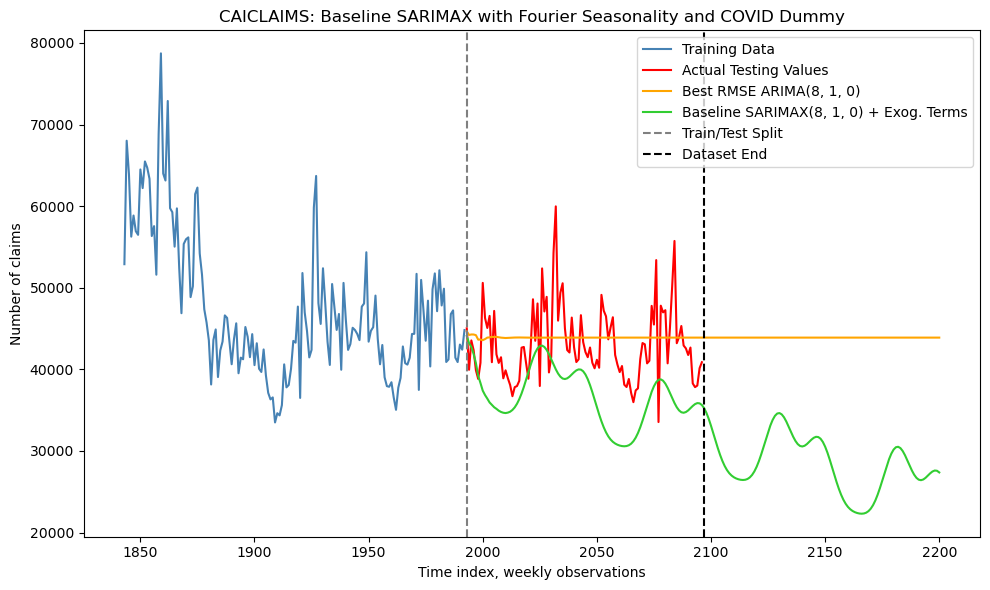

Root Mean Squared Error of Best RMSE ARIMA(8, 1, 0) Model: 4599.134
Root Mean Squared Error of Baseline SARIMAX(8, 1, 0) Model: 7840.432


In [33]:
## Forecast the test period plus an additional 2-year future window.
sarimax_fcast = sarimax_model.get_forecast(steps=len(ytest_CA) + test_horizon, exog=Xtest_CA_extended)
sarimax_yhat = sarimax_fcast.predicted_mean
sarimax_yhat.index = tpred
sarimax_rmse = np.sqrt(mean_squared_error(ytest_CA, sarimax_yhat.iloc[:len(ytest_CA)]))


## Plot predictions against ARIMA baselines and actual values.
plt.figure(figsize=(10, 6))
plt.plot(ttrain[(train_end - 150):], ytrain_CA.iloc[(train_end - 150):], label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Actual Testing Values", color="red")

plt.plot(tpred, best_rmse_yhat, color="orange",
         label=f"Best RMSE ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])})")
plt.plot(tpred, sarimax_yhat, color="limegreen",
         label=f"Baseline SARIMAX({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) + Exog. Terms")

plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split" )
plt.axvline(x=len(y_CA), color="black", linestyle="--", label="Dataset End")

plt.title("CAICLAIMS: Baseline SARIMAX with Fourier Seasonality and COVID Dummy")
plt.xlabel("Time index, weekly observations")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();


print(f"Root Mean Squared Error of Best RMSE ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) Model: {best_rmse_rmse:.3f}")
print(f"Root Mean Squared Error of Baseline SARIMAX({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) Model: {sarimax_rmse:.3f}")

### **Parameter Selection (Grid Search)**

**Code cell purpose:** Cell below defines the SARIMAX grid-search helper for post-COVID speciifcation. 

In [34]:
## Parameters
pmax, dmax, qmax = 8, 1, 6

## Brief function
def fit_sarimax_exog(params):
    p, d, q = map(int, params)
    try:
        model = SARIMAX(ytrain_CA, exog=Xtrain_CA, order=(p, d, q), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        y_hat = model.get_forecast(steps=len(ytest_CA), exog=Xtest_CA).predicted_mean
        y_hat.index = ytest_CA.index
        rmse = np.sqrt(mean_squared_error(ytest_CA, y_hat))
        return {"p": p, "d": d, "q": q, "AIC": model.aic, "BIC": model.bic, "RMSE": rmse}
    except Exception:
        return None


**Code cell purpose:** Running/loading the SARIMAX grid search for post-COVID specification. 

In [35]:
## Setting up the path
cache_path_sarimax = "sarimax_grid_results_CAICLAIMS.csv"

## Grid for parameters
param_grid = list(itertools.product(
    range(pmax + 1),
    range(dmax + 1),
    range(qmax + 1)
))

## Necessary columns
required_sarimax_cols = {"p", "d", "q", "AIC", "BIC", "RMSE"}

## Setting up the process
if os.path.exists(cache_path_sarimax):
    print(f"Loading cached SARIMAX grid search results from {cache_path_sarimax}")
    results_sarimax_df = pd.read_csv(cache_path_sarimax)

    ## Re-run if the cache is not in the expected format
    if not required_sarimax_cols.issubset(results_sarimax_df.columns):
        print("Cached SARIMAX results are missing the required columns, so the grid search needs to be run again!")
        results_sarimax_df = pd.DataFrame()

else:
    results_sarimax_df = pd.DataFrame()

if results_sarimax_df.empty:
    print("Running SARIMAX grid search!")

    results_sarimax = Parallel(n_jobs=-1, verbose=10)(
        delayed(fit_sarimax_exog)(params) for params in param_grid
    )

    results_sarimax = [r for r in results_sarimax if r is not None]
    results_sarimax_df = pd.DataFrame(results_sarimax)

    if results_sarimax_df.empty:
        raise ValueError(
            "SARIMAX grid search failed, meaning no models were successfully fit!"
            "Please check that len(Xtest_CA) equals len(ytest_CA)."
        )

    results_sarimax_df.to_csv(cache_path_sarimax, index=False)
    print(f"Saved SARIMAX grid search results to {cache_path_sarimax}")

## Showing the best few models by holdout RMSE for transparency
display(results_sarimax_df.sort_values("RMSE").head(10).round(3))

Loading cached SARIMAX grid search results from sarimax_grid_results_CAICLAIMS.csv


,p,d,q,AIC,BIC,RMSE
7,0,1,0,"58,858.05","58,908.42","7,120.88"
120,8,1,1,"45,310.04","45,410.71","7,139.81"
109,7,1,4,"45,332.23","45,444.10","7,153.02"
97,6,1,6,"45,336.91","45,454.37","7,161.53"
83,5,1,6,"45,334.92","45,446.79","7,163.80"
69,4,1,6,"45,332.86","45,439.14","7,166.95"
95,6,1,4,"45,355.52","45,461.80","7,167.27"
121,8,1,2,"45,310.80","45,417.06","7,171.70"
122,8,1,3,"45,312.05","45,423.91","7,172.84"
82,5,1,5,"45,354.77","45,461.05","7,174.10"


### **Best Models by Evaluation Metrics**

**Code cell purpose:** Extracting the best SARIMAX specifications according to the metrics of AIC, BIC, and holdout RMSE.


In [36]:
## BEst specifications
best_aic_sarimax = results_sarimax_df.loc[results_sarimax_df["AIC"].idxmin()]
best_bic_sarimax = results_sarimax_df.loc[results_sarimax_df["BIC"].idxmin()]
best_rmse_sarimax = results_sarimax_df.loc[results_sarimax_df["RMSE"].idxmin()]

## Printing out respective messages for metrics
print(
    f"Best model by AIC: SARIMAX({int(best_aic_sarimax['p'])}, "
    f"{int(best_aic_sarimax['d'])}, {int(best_aic_sarimax['q'])}), "
    f"AIC: {best_aic_sarimax['AIC']:.3f}, "
    f"BIC: {best_aic_sarimax['BIC']:.3f}, "
    f"RMSE: {best_aic_sarimax['RMSE']:.3f}"
)

print(
    f"Best model by BIC: SARIMAX({int(best_bic_sarimax['p'])}, "
    f"{int(best_bic_sarimax['d'])}, {int(best_bic_sarimax['q'])}), "
    f"AIC: {best_bic_sarimax['AIC']:.3f}, "
    f"BIC: {best_bic_sarimax['BIC']:.3f}, "
    f"RMSE: {best_bic_sarimax['RMSE']:.3f}"
)

print(
    f"Best model by RMSE: SARIMAX({int(best_rmse_sarimax['p'])}, "
    f"{int(best_rmse_sarimax['d'])}, {int(best_rmse_sarimax['q'])}), "
    f"AIC: {best_rmse_sarimax['AIC']:.3f}, "
    f"BIC: {best_rmse_sarimax['BIC']:.3f}, "
    f"RMSE: {best_rmse_sarimax['RMSE']:.3f}"
)

Best model by AIC: SARIMAX(8, 1, 1), AIC: 45310.035, BIC: 45410.707, RMSE: 7139.811
Best model by BIC: SARIMAX(8, 1, 1), AIC: 45310.035, BIC: 45410.707, RMSE: 7139.811
Best model by RMSE: SARIMAX(0, 1, 0), AIC: 58858.051, BIC: 58908.419, RMSE: 7120.883


**Code cell purpose:** Cell fits best holdout-RMSE SARIMAX model, also prints out summary.


In [37]:
## Best values
best_p = int(best_rmse_sarimax["p"])
best_d = int(best_rmse_sarimax["d"])
best_q = int(best_rmse_sarimax["q"])

## Best model
best_rmse_sarimax_model = SARIMAX(
    ytrain_CA,
    exog=Xtrain_CA_extended,
    order=(best_p, best_d, best_q),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

print(best_rmse_sarimax_model.summary())

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1993
Model:               SARIMAX(0, 1, 0)   Log Likelihood              -29420.026
Date:                Fri, 01 May 2026   AIC                          58858.051
Time:                        01:13:38   BIC                          58908.419
Sample:                             0   HQIC                         58876.550
                               - 1993                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
trend         -79.4505   2.55e+06  -3.11e-05      1.000   -5.01e+06    5.01e+06
sin_1        2431.3356    3.2e+07    7.6e-05      1.000   -6.27e+07    6.27e+07
cos_1        3340.7817   2.83e+07      0.000    

### **Plotting the SARIMAX Predictions**

**Code cell purpose:** Plotting entire California train-test split to have clear visualization of the forecasting setup.


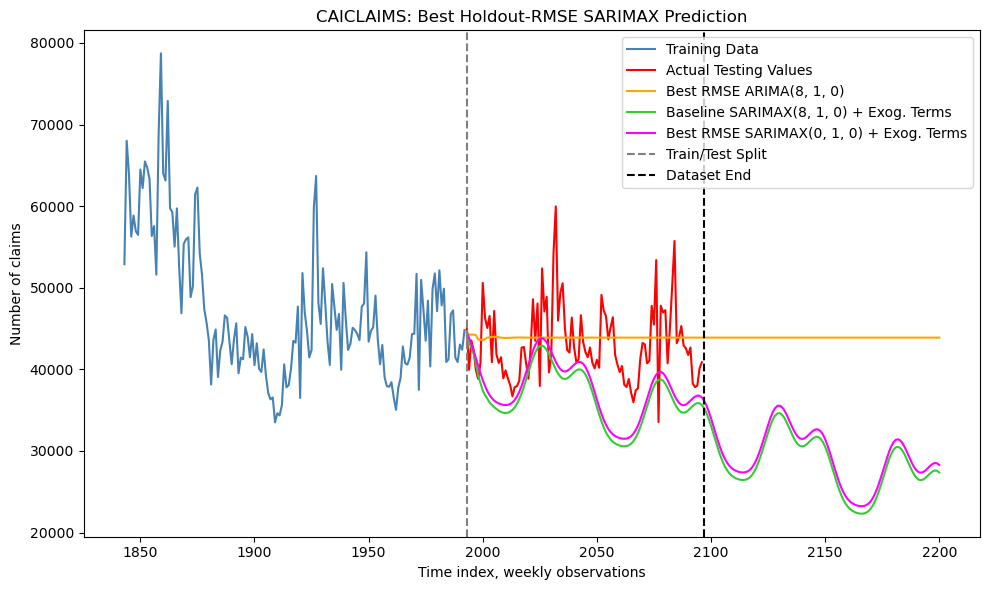

Root Mean Squared Error of Best RMSE ARIMA(8, 1, 0) Model: 4599.134
Root Mean Squared Error of Baseline SARIMAX(8, 1, 0) Model: 7840.432
Root Mean Squared Error of Best RMSE SARIMAX(0, 1, 0) Model: 7120.883


In [38]:
## Our best forcasting model
best_rmse_sarimax_fcast = best_rmse_sarimax_model.get_forecast(
    steps=len(ytest_CA) + test_horizon,
    exog=Xtest_CA_extended
)

## Best predictors
best_rmse_sarimax_yhat = best_rmse_sarimax_fcast.predicted_mean
best_rmse_sarimax_yhat.index = tpred
best_sarimax_rmse = np.sqrt(mean_squared_error(ytest_CA, best_rmse_sarimax_yhat.iloc[:len(ytest_CA)]))

## Plotting
plt.figure(figsize=(10, 6))
plt.plot(ttrain[(train_end - 150):], ytrain_CA.iloc[(train_end - 150):], label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Actual Testing Values", color="red")

plt.plot(tpred, best_rmse_yhat, color="orange",
         label=f"Best RMSE ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])})")
plt.plot(tpred, sarimax_yhat, color="limegreen",
         label=f"Baseline SARIMAX({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) + Exog. Terms")
plt.plot(tpred, best_rmse_sarimax_yhat, color="magenta",
         label=f"Best RMSE SARIMAX({best_p}, {best_d}, {best_q}) + Exog. Terms")

plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split")
plt.axvline(x=len(y_CA), color="black", linestyle="--", label="Dataset End")

plt.title("CAICLAIMS: Best Holdout-RMSE SARIMAX Prediction")
plt.xlabel("Time index, weekly observations")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();


print(f"Root Mean Squared Error of Best RMSE ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) Model: {best_rmse_rmse:.3f}")
print(f"Root Mean Squared Error of Baseline SARIMAX({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) Model: {sarimax_rmse:.3f}")
print(f"Root Mean Squared Error of Best RMSE SARIMAX({best_p}, {best_d}, {best_q}) Model: {best_sarimax_rmse:.3f}")

## **3. SARIMAX with Fourier Frequencies, During COVID Dummy**

**Code cell purpose:** Plotting entire California train-test split so forecasting setup is visually clear.


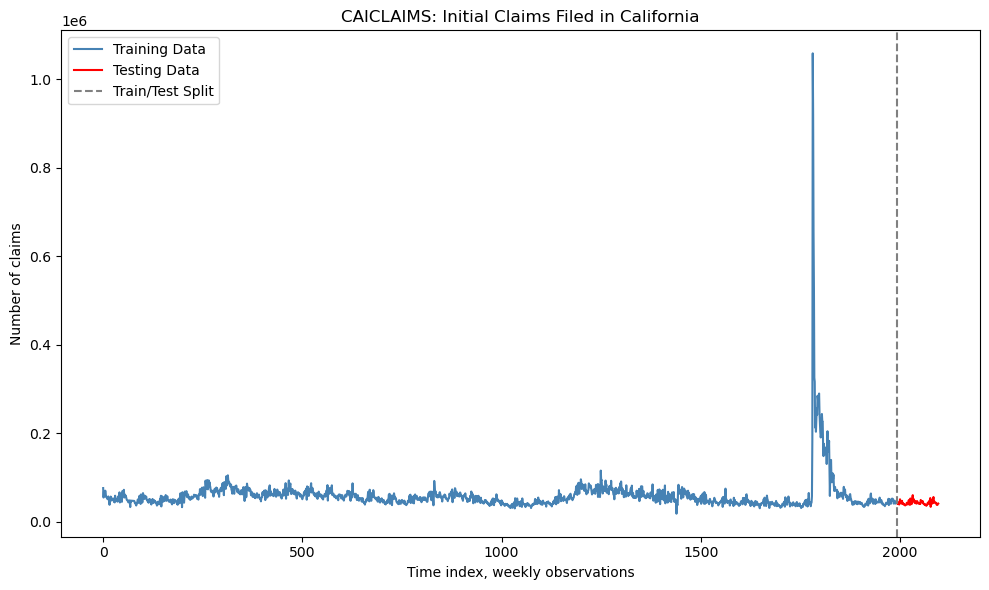

In [39]:
## Plotting
plt.figure(figsize=(10, 6))
plt.plot(ttrain, ytrain_CA, label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Testing Data", color="red")
plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split")
plt.title("CAICLAIMS: Initial Claims Filed in California")
plt.xlabel("Time index, weekly observations")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();

**Code cell purpose:** Replotting initial differences prior to SARIMAX section so that we keep the model diagnostics similar to the model code. 

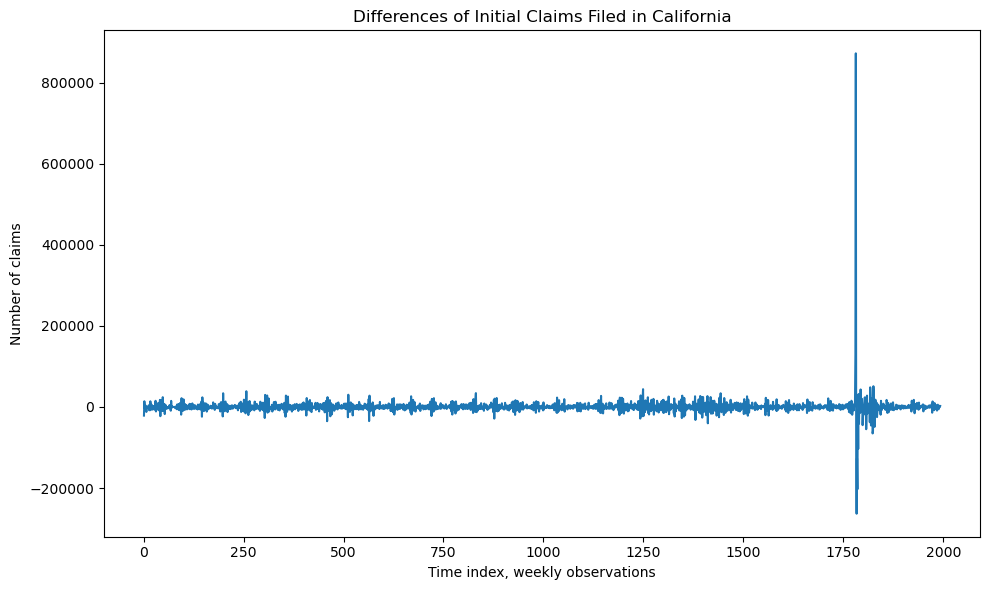

In [40]:
## Plotting
plt.figure(figsize=(10,6))
plt.plot(ytrain_CA_diff.dropna())
plt.xlabel("Time index, weekly observations")
plt.ylabel("Number of claims")
plt.title("Differences of Initial Claims Filed in California")
plt.tight_layout()
plt.show();

### **Design Matrix Construction**

**Code cell purpose:** Defines alternative SARIMAX feature set with a during-COVID indicator instead of a post-COVID indicator.

In [41]:
## Brief function
def make_features_new(n, covid_start=1775, covid_end=1860, n_harmonics=3):
    t = np.arange(n)
    X = pd.DataFrame({"trend": t}, index=np.arange(n))
    for k in range(1, n_harmonics + 1):
        X[f"sin_{k}"] = np.sin(2 * np.pi * k * t / 52)
        X[f"cos_{k}"] = np.cos(2 * np.pi * k * t / 52)
    X["during_covid"] = ((t >= covid_start) & (t <= covid_end)).astype(int)
    return X


**Code cell purpose:** Builds observed and extended feature matrices for the during-COVID SARIMAX specification.


In [42]:
## Exog features through observed data only (for holdout RMSE/grid search)
X_CA_new = make_features_new(n=len(y_CA), covid_start=1775, covid_end=1860, n_harmonics=3)

## Training/Test set
Xtrain_CA_new = X_CA_new.iloc[:train_end]
Xtest_CA_new = X_CA_new.iloc[train_end:len(y_CA)]
Xtest_CA_new = Xtest_CA_new[Xtrain_CA_new.columns]

## Exog through observed data and future period (for extended future forecasts)
X_CA_new_extended = make_features_new(n=len(y_CA) + test_horizon, covid_start=1775, covid_end=1860, n_harmonics=3)

## Extended model
Xtrain_CA_new_extended = X_CA_new_extended.iloc[:train_end]
Xtest_CA_new_extended = X_CA_new_extended.iloc[train_end : len(y_CA) + test_horizon]
Xtest_CA_new_extended = Xtest_CA_new_extended[Xtrain_CA_new_extended.columns]

### **Parameter Selection (Grid Search)**

**Code cell purpose:** Cell below sets up a couple of brief functions to define short rolling-origin cross-validation helpers, specifically for the SARIMAX (during-COVID) specification.

In [43]:
## Row function
def cv_row(order, train_end_cv, horizon, rmse, aic, bic, status):
    p, d, q = map(int, order)
    return {"train_end": train_end_cv, "test_start": train_end_cv, "test_end": train_end_cv + horizon - 1, "p": p, "d": d, "q": q, "RMSE": rmse, "AIC": aic, "BIC": bic, "status": status}

## Necessary slicing
def cv_slices(y, X, train_end_cv, horizon):
    y_train = y.iloc[:train_end_cv]
    y_test = y.iloc[train_end_cv:train_end_cv + horizon]
    X_train = X.iloc[:train_end_cv]
    X_test = X.iloc[train_end_cv:train_end_cv + horizon][X_train.columns]
    return y_train, y_test, X_train, X_test

## Fitting function
def cv_fit_one(y, X, order, train_end_cv, horizon):
    y_train, y_test, X_train, X_test = cv_slices(y, X, train_end_cv, horizon)
    try:
        model = SARIMAX(y_train, exog=X_train, order=tuple(map(int, order)), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        y_hat = model.get_forecast(steps=horizon, exog=X_test).predicted_mean
        rmse = np.sqrt(mean_squared_error(y_test, y_hat))
        return cv_row(order, train_end_cv, horizon, rmse, model.aic, model.bic, "success")
    except Exception:
        return cv_row(order, train_end_cv, horizon, np.nan, np.nan, np.nan, "failed")

## Producing summary
def cv_summary(order, cv_results):
    p, d, q = map(int, order)
    return {"p": p, "d": d, "q": q, "CV_RMSE": cv_results["RMSE"].mean(skipna=True), "CV_AIC": cv_results["AIC"].mean(skipna=True), "CV_BIC": cv_results["BIC"].mean(skipna=True), "n_success": cv_results["RMSE"].notna().sum(), "n_splits": len(cv_results)}

## Rolling-origin
def rolling_cv_sarimax(y, X, order, initial_train_size=1500, horizon=52, step=26):
    y = pd.Series(y).reset_index(drop=True)
    X = X.reset_index(drop=True)
    split_points = range(initial_train_size, len(y) - horizon + 1, step)
    rows = [cv_fit_one(y, X, order, split, horizon) for split in split_points]
    return cv_summary(order, pd.DataFrame(rows))


**Code cell purpose:** Runs/loads the rolling-origin cross-validation for SARIMAX during-COVID grid.


In [44]:
## Path
cache_path = "sarimax_cv_grid_results_CAICLAIMS.csv"

## Parameters
pmax, dmax, qmax = 8, 1, 6

## Parameter grid
param_grid = list(itertools.product(
    range(pmax + 1),
    range(dmax + 1),
    range(qmax + 1)
))

## Initial setups
initial_train_size = 1500
horizon = 52
step = 26

## Brief function for order evaluation
def evaluate_order_cv(order):
    return rolling_cv_sarimax(
        y=ytrain_CA, X=Xtrain_CA_new, order=order,
        initial_train_size=initial_train_size, horizon=horizon, step=step
    )

## Necessary columns
required_cv_cols = {"p", "d", "q", "CV_RMSE", "CV_AIC", "CV_BIC", "n_success", "n_splits"}

## Running everything
if os.path.exists(cache_path):
    print(f"Loading cached grid search results from {cache_path}")
    results_sarimax_new_df = pd.read_csv(cache_path)

    ## Re-run if the cache is not in the expected format.
    if not required_cv_cols.issubset(results_sarimax_new_df.columns):
        print("Cached rolling-CV SARIMAX results are missing required columns, so the grid search needs to be run again!")
        results_sarimax_new_df = pd.DataFrame()

else:
    results_sarimax_new_df = pd.DataFrame()

if results_sarimax_new_df.empty:
    print("Running SARIMAX rolling-CV grid search!")

    results_sarimax_new = Parallel(n_jobs=-1, verbose=10)(
        delayed(evaluate_order_cv)(order) for order in param_grid
    )

    results_sarimax_new_df = pd.DataFrame(results_sarimax_new)

    ## Saving cache so the notebook can be run again quickly
    results_sarimax_new_df.to_csv(cache_path, index=False)
    print(f"Saved grid search results to {cache_path}")


Loading cached grid search results from sarimax_cv_grid_results_CAICLAIMS.csv


### **Best Models by Evaluation Metrics**

**Code cell purpose:** Cell below completes cleaning and ranking of the rolling-CV SARIMAX grid results by cross-validation RMSE.


In [50]:
## Clean and sort results
results_sarimax_new_df = results_sarimax_new_df.dropna(subset=["CV_RMSE"])
results_sarimax_new_df = results_sarimax_new_df.sort_values("CV_RMSE").reset_index(drop=True)

print("Top SARIMAX models by rolling-origin CV RMSE:")
display(results_sarimax_new_df.head(10))

Top SARIMAX models by rolling-origin CV RMSE:


,p,d,q,CV_RMSE,CV_AIC,CV_BIC,n_success,n_splits
0,0,1,1,"47,712.63","36,588.57","36,642.95",17,17
1,1,1,0,"47,925.95","36,835.75","36,890.14",17,17
2,0,1,0,"48,233.20","48,112.16","48,161.11",17,17
3,0,1,5,"48,303.72","36,424.06","36,500.17",17,17
4,2,1,3,"48,985.65","36,554.06","36,630.18",17,17
5,2,1,6,"49,343.47","36,380.53","36,472.94",17,17
6,2,1,5,"49,509.07","36,401.95","36,488.93",17,17
7,1,1,3,"49,546.19","36,467.11","36,537.79",17,17
8,1,1,2,"49,645.13","36,497.52","36,562.78",17,17
9,1,1,6,"49,664.51","36,398.65","36,485.62",17,17


**Code cell purpose:** Cell stores the best rolling-CV SARIMAX order, also prints its CV diagnostics.


In [51]:
## Generating new object
best_rmse_sarimax_new = results_sarimax_new_df.iloc[0]

## Best of different parameters
best_p_new = int(best_rmse_sarimax_new['p'])
best_d_new = int(best_rmse_sarimax_new['d'])
best_q_new = int(best_rmse_sarimax_new['q'])

## Printing
print(f"Best SARIMAX by rolling CV: SARIMAX({best_p_new}, {best_d_new}, {best_q_new})")
print(f"CV RMSE: {best_rmse_sarimax_new['CV_RMSE']:.3f}")
print(f"CV AIC: {best_rmse_sarimax_new['CV_AIC']:.3f}")
print(f"CV BIC: {best_rmse_sarimax_new['CV_BIC']:.3f}")
print(f"Successful CV splits: {int(best_rmse_sarimax_new['n_success'])} / {int(best_rmse_sarimax_new['n_splits'])}")

Best SARIMAX by rolling CV: SARIMAX(0, 1, 1)
CV RMSE: 47712.634
CV AIC: 36588.570
CV BIC: 36642.955
Successful CV splits: 17 / 17


### **Final Holdout Evaluation**

**Code cell purpose:** Forecasting from the baseline SARIMAX model and makes direct comparison with the ARIMA baseline.


In [52]:
## Best SARIMAX model
best_rmse_sarimax_model_new = SARIMAX(
    ytrain_CA,
    exog=Xtrain_CA_new_extended,
    order=(best_p_new, best_d_new, best_q_new),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

## Summary
print(best_rmse_sarimax_model_new.summary())

## Forecasting!
best_rmse_sarimax_fcast_new = best_rmse_sarimax_model_new.get_forecast(
    steps=len(ytest_CA) + test_horizon,
    exog=Xtest_CA_new_extended
)

best_rmse_sarimax_yhat_new = best_rmse_sarimax_fcast_new.predicted_mean
best_rmse_sarimax_yhat_new.index = tpred
best_sarimax_rmse_new = np.sqrt(mean_squared_error(ytest_CA, best_rmse_sarimax_yhat_new.iloc[:len(ytest_CA)]))

print(f"\nFinal 2-year holdout RMSE for Best Rolling-CV SARIMAX({best_p_new}, {best_d_new}, {best_q_new}) Model: {best_sarimax_rmse_new:.3f}")

                               SARIMAX Results                                
Dep. Variable:                 Claims   No. Observations:                 1993
Model:               SARIMAX(0, 1, 1)   Log Likelihood              -22855.555
Date:                Fri, 01 May 2026   AIC                          45731.110
Time:                        01:16:17   BIC                          45787.069
Sample:                             0   HQIC                         45751.662
                               - 1993                                         
Covariance Type:                  opg                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
trend          -16.0757   1329.037     -0.012      0.990   -2620.940    2588.788
sin_1         2611.3769   1.67e+04      0.157      0.875      -3e+04    3.53e+04
cos_1         2341.5993   1.47e+04      0.15

### **Plotted SARIMAX Predictions**

**Code cell purpose:** This cell plots the entire California train-test split so the forecasting setup is visually clear.


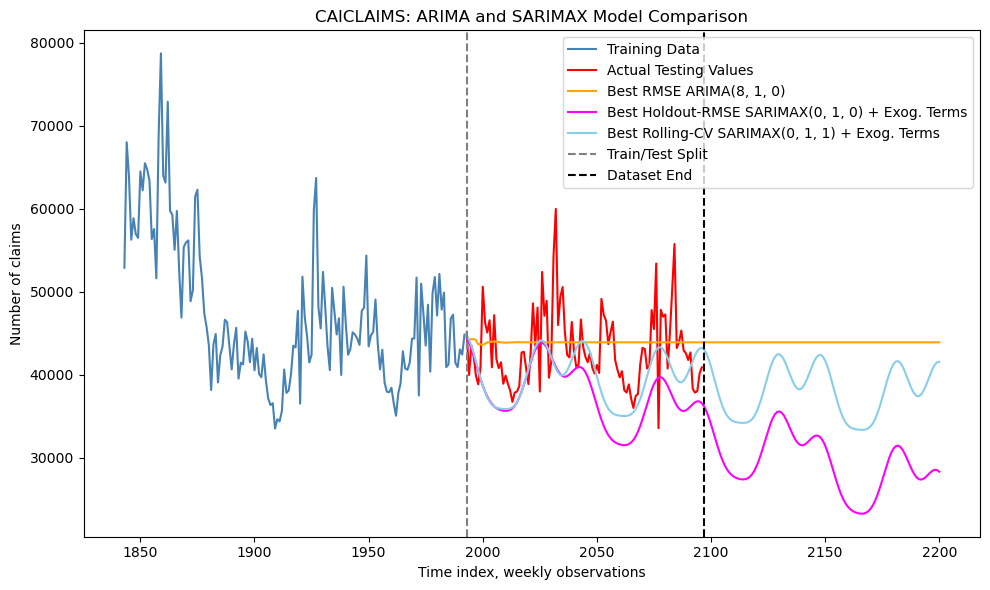

Root Mean Squared Error of Best RMSE ARIMA(8, 1, 0) Model: 4599.134
Root Mean Squared Error of Best Holdout-RMSE SARIMAX(0, 1, 0) Model: 7120.883
Root Mean Squared Error of Best Rolling-CV SARIMAX(0, 1, 1) Model: 5764.098


In [53]:
## Setting up figure
plt.figure(figsize=(10, 6))
plt.plot(ttrain[(train_end - 150):], ytrain_CA.iloc[(train_end - 150):], label="Training Data", color="steelblue")
plt.plot(ttest, ytest_CA, label="Actual Testing Values", color="red")

## Plotting
plt.plot(tpred, best_rmse_yhat, color="orange",
         label=f"Best RMSE ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])})")
plt.plot(tpred, best_rmse_sarimax_yhat, color="magenta",
         label=f"Best Holdout-RMSE SARIMAX({best_p}, {best_d}, {best_q}) + Exog. Terms")
plt.plot(tpred, best_rmse_sarimax_yhat_new, color="skyblue",
         label=f"Best Rolling-CV SARIMAX({best_p_new}, {best_d_new}, {best_q_new}) + Exog. Terms")

plt.axvline(x=train_end, color="gray", linestyle="--", label="Train/Test Split")
plt.axvline(x=len(y_CA), color="black", linestyle="--", label="Dataset End")

plt.title("CAICLAIMS: ARIMA and SARIMAX Model Comparison")
plt.xlabel("Time index, weekly observations")
plt.ylabel("Number of claims")
plt.legend(); plt.tight_layout(); plt.show();

## Printing
print(f"Root Mean Squared Error of Best RMSE ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) Model: {best_rmse_rmse:.3f}")
print(f"Root Mean Squared Error of Best Holdout-RMSE SARIMAX({best_p}, {best_d}, {best_q}) Model: {best_sarimax_rmse:.3f}")
print(f"Root Mean Squared Error of Best Rolling-CV SARIMAX({best_p_new}, {best_d_new}, {best_q_new}) Model: {best_sarimax_rmse_new:.3f}")

### **Model Comparison Table**

Table below provides a succint summary of the main models utilized for prediction here. What is most relevant for report/discussion is the 2-year holdout RMSE, that of which evaluates how effective any given model is at predicting observations which were not utilized in training!

**Code cell purpose:** Cell below generates concise comparison table for the main ARIMA and SARIMAX specifications.


In [1]:
## Building the table in a succint dataframe format!
model_comparison = pd.DataFrame([
    {
        "model": f"ARIMA({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])})",
        "selection_rule": "Best holdout RMSE among ARIMA grid",
        "holdout_rmse": best_rmse_rmse
    },
    {
        "model": f"SARIMAX({int(best_rmse['p'])}, {int(best_rmse['d'])}, {int(best_rmse['q'])}) + Fourier + after-COVID dummy",
        "selection_rule": "Uses best ARIMA order, then adds exog terms",
        "holdout_rmse": sarimax_rmse
    },
    {
        "model": f"SARIMAX({best_p}, {best_d}, {best_q}) + Fourier + after-COVID dummy",
        "selection_rule": "Best holdout RMSE among SARIMAX grid",
        "holdout_rmse": best_sarimax_rmse
    },
    {
        "model": f"SARIMAX({best_p_new}, {best_d_new}, {best_q_new}) + Fourier + during-COVID dummy",
        "selection_rule": "Best rolling-CV RMSE among SARIMAX grid",
        "holdout_rmse": best_sarimax_rmse_new
    }
])

## Displaying results!
display(model_comparison.sort_values("holdout_rmse").round(3))

NameError: name 'pd' is not defined